# LUMIERE Glioblastoma — Exploratory Data Analysis

**Goal of the overall project:** a longitudinal tumour-tracking pipeline (segmentation → RANO-based disease tracking).
**Goal of this notebook:** EDA to understand the dataset before building that pipeline.

The [LUMIERE dataset](https://doi.org/10.1038/s41597-022-01881-7) (Suter et al., *Sci Data* 2022) contains **91 glioblastoma patients** with longitudinal MRI, expert **RANO** response ratings, two automated segmentations (**DeepBraTumIA**, **HD-GLIO-AUTO**) and pyradiomics features.

### How this notebook is organised
| Module | Focus |
|---|---|
| **M0** | Setup, data loading, helpers (incl. zip-streaming of imaging) |
| **M1** | Cohort characterisation (demographics, molecular markers) |
| **M1b** | Survival (Kaplan–Meier by MGMT / IDH) |
| **M2** | Longitudinal timeline structure (swimmer plot, scan intervals) |
| **M3** | RANO label analysis (distribution, transitions, time-to-progression, pseudoprogression) |
| **M4** | RANO rationale text-mining (bidimensional SPD, lesion flags) |
| **M5** | Imaging completeness, scanner heterogeneity, label-convention check |
| **M6** | Segmentation-derived volumetrics (trajectories vs RANO) |
| **M7** | 2D (Macdonald/RANO) vs 3D (volumetric) |
| **M8** | Inter-method agreement (DeepBraTumIA vs HD-GLIO-AUTO) |
| **M9** | Voxel-level visual EDA (segmentation overlays, streamed from the zip) |
| **M10** | Full radiomics EDA (redundancy, PCA, what changes at progression) |
| **M11** | Data-quality / trackability synthesis |

> **Disk note:** the imaging archive (`Imaging-v202211.zip`, ~32.5 GB) is **not extracted**. NIfTI volumes are read **directly from the zip on demand** (see `load_nifti_from_zip`), so no large extraction is needed.

## M0 — Setup, data loading & helpers

In [1]:
import os, io, gzip, zipfile, json, re, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import nibabel as nib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

DATA_DIR = Path("/Users/prateekkarkare/Desktop/Personal/Projects/lumiere")
ZIP_PATH = DATA_DIR / "Imaging-v202211.zip"

print("Data dir       :", DATA_DIR)
print("Imaging zip    :", ZIP_PATH.name, "-> exists:", ZIP_PATH.exists(),
      f"({ZIP_PATH.stat().st_size/1e9:.1f} GB)" if ZIP_PATH.exists() else "")

Data dir       : /Users/prateekkarkare/Desktop/Personal/Projects/lumiere
Imaging zip    : Imaging-v202211.zip -> exists: True (32.6 GB)


In [2]:
# ---- Load the six CSVs ----
demo     = pd.read_csv(DATA_DIR / "LUMIERE-Demographics_Pathology.csv")
rano     = pd.read_csv(DATA_DIR / "LUMIERE-ExpertRating-v202211.csv")
complete = pd.read_csv(DATA_DIR / "LUMIERE-datacompleteness.csv")
mrinfo   = pd.read_csv(DATA_DIR / "LUMIERE-MRinfo.csv")
rad_dbt  = pd.read_csv(DATA_DIR / "LUMIERE-pyradiomics-deepbratumia-features.csv")
rad_hdg  = pd.read_csv(DATA_DIR / "LUMIERE-pyradiomics-hdglioauto-features.csv")

# The RANO rating/rationale headers are very long -> give them short names
rano = rano.rename(columns={rano.columns[4]: "Rating", rano.columns[5]: "Rationale"})

for name, df in [("demographics", demo), ("rano", rano), ("completeness", complete),
                 ("mrinfo", mrinfo), ("radiomics_DBT", rad_dbt), ("radiomics_HDG", rad_hdg)]:
    print(f"{name:16s} {str(df.shape):>12s}")

demographics          (91, 8)
rano                 (616, 6)
completeness        (638, 10)
mrinfo             (2487, 24)
radiomics_DBT     (7188, 152)
radiomics_HDG     (4792, 152)


In [3]:
# ---- Helpers: timepoint parsing & categorical cleaning ----
def parse_timepoint(tp):
    "week-044 -> (44, None); week-000-2 -> (0, 2)"
    m = re.match(r"week-(\d+)(?:-(\d+))?$", str(tp).strip())
    if not m:
        return (np.nan, None)
    return (int(m.group(1)), int(m.group(2)) if m.group(2) else None)

def clean_idh(v):
    v = str(v).strip().lower()
    if "r132" in v or "mut" in v:  return "mutant"
    if "wt" in v or "wild" in v:   return "wildtype"
    if "neg" in v:                 return "IDH1-neg (seq. required)"
    return "unknown"

def clean_mgmt(v):
    v = str(v).strip().lower()
    if v in ("na", "nan", ""):     return np.nan
    return v

# ---- Helpers: read imaging directly from the zip (no extraction) ----
_ZF = None
def zf():
    global _ZF
    if _ZF is None:
        _ZF = zipfile.ZipFile(ZIP_PATH)
    return _ZF

def load_nifti_from_zip(member):
    raw = zf().read(member)
    fh = nib.FileHolder(fileobj=gzip.GzipFile(fileobj=io.BytesIO(raw)))
    return nib.Nifti1Image.from_file_map({"header": fh, "image": fh})

def load_json_from_zip(member):
    return json.loads(zf().read(member))

# ---- Member-path builders (verified against the archive layout) ----
def m_image(patient, tp, seq):        # seq in {CT1,T1,T2,FLAIR}
    return f"Imaging/{patient}/{tp}/{seq}.nii.gz"
def m_dbt_mask(patient, tp):
    return f"Imaging/{patient}/{tp}/DeepBraTumIA-segmentation/atlas/segmentation/seg_mask.nii.gz"
def m_dbt_vol(patient, tp):
    return f"Imaging/{patient}/{tp}/DeepBraTumIA-segmentation/atlas/segmentation/measured_volumes_in_mm3.json"
def m_dbt_ss(patient, tp, seq):       # seq lower-case, atlas skull-stripped image
    return f"Imaging/{patient}/{tp}/DeepBraTumIA-segmentation/atlas/skull_strip/{seq}_skull_strip.nii.gz"
def m_hdg_mask(patient, tp):
    return f"Imaging/{patient}/{tp}/HD-GLIO-AUTO-segmentation/registered/segmentation.nii.gz"

ZIP_MEMBERS = set(zf().namelist())
print("Zip members indexed:", len(ZIP_MEMBERS))

Zip members indexed: 31370


In [4]:
# ---- Apply base cleaning once, shared by all downstream modules ----
# Timepoints
rano[["week", "subtp"]] = rano["Date"].apply(lambda t: pd.Series(parse_timepoint(t)))
rano["Rating_clean"] = (rano["Rating"].astype(str).str.strip()
                        .replace({"Post-Op/PD": "PD", "None": np.nan, "nan": np.nan}))
rano["lt3m"]   = rano["LessThan3Months"].astype(str).str.strip().eq("x")
rano["nonmeas"] = rano["NonMeasurableLesions"].astype(str).str.strip().eq("x")

# Demographics
demo["Sex"]            = demo["Sex"].astype(str).str.strip().str.lower()
demo["IDH_clean"]      = demo["IDH (WT: wild type)"].apply(clean_idh)
demo["MGMT_clean"]     = demo["MGMT qualitative"].apply(clean_mgmt)
demo["Survival_weeks"] = pd.to_numeric(demo["Survival time (weeks)"], errors="coerce")
demo["Age"]            = pd.to_numeric(demo["Age at surgery (years)"], errors="coerce")

RANO_ORDER   = ["Pre-Op", "Post-Op", "CR", "PR", "SD", "PD"]
RANO_PALETTE = {"Pre-Op": "#9e9e9e", "Post-Op": "#4C72B0", "CR": "#2ca02c",
                "PR": "#8172B3", "SD": "#55A868", "PD": "#C44E52"}

print("Patients (demographics):", demo["Patient"].nunique())
print("Patients (RANO)        :", rano["Patient"].nunique())
print("RANO rows              :", len(rano))
print("Cleaned RANO ratings   :", rano['Rating_clean'].value_counts(dropna=False).to_dict())

Patients (demographics): 91
Patients (RANO)        : 91
RANO rows              : 616
Cleaned RANO ratings   : {'PD': 254, 'Post-Op': 124, 'SD': 97, 'Pre-Op': 92, 'CR': 27, 'PR': 20, nan: 2}


## M1 — Cohort characterisation

Static, patient-level view: age, sex, and the two molecular markers that dominate GBM prognosis — **IDH** status and **MGMT** promoter methylation.

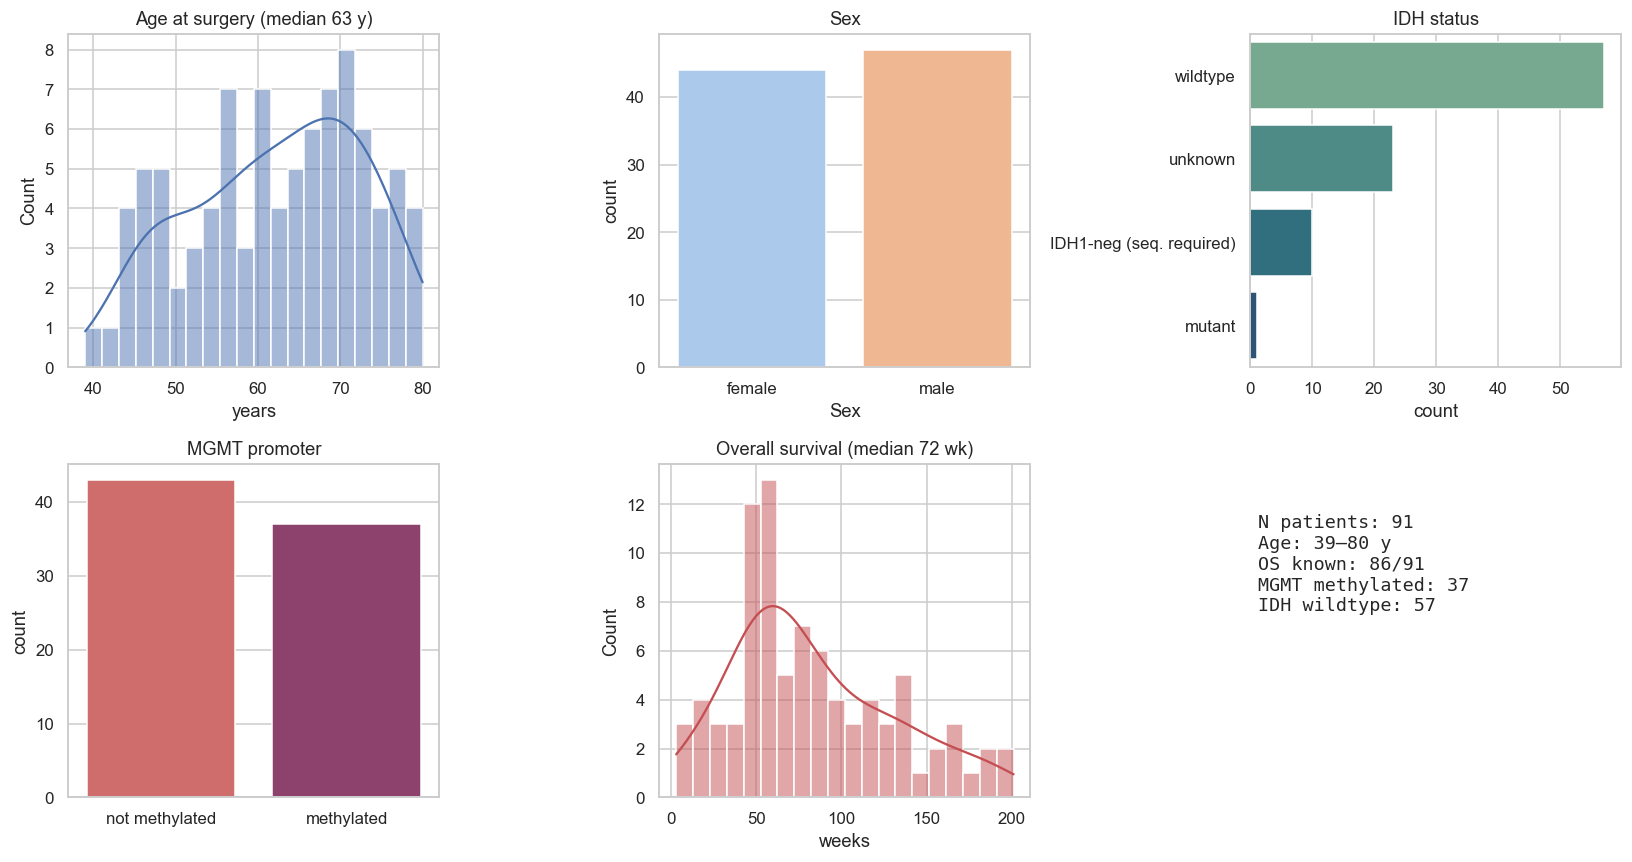

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(demo["Age"].dropna(), bins=20, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title(f"Age at surgery (median {demo['Age'].median():.0f} y)")
axes[0, 0].set_xlabel("years")

sns.countplot(x="Sex", data=demo, ax=axes[0, 1], palette="pastel")
axes[0, 1].set_title("Sex")

sns.countplot(y="IDH_clean", data=demo, ax=axes[0, 2],
              order=demo["IDH_clean"].value_counts().index, palette="crest")
axes[0, 2].set_title("IDH status"); axes[0, 2].set_ylabel("")

sns.countplot(x="MGMT_clean", data=demo, ax=axes[1, 0],
              order=demo["MGMT_clean"].value_counts().index, palette="flare")
axes[1, 0].set_title("MGMT promoter"); axes[1, 0].set_xlabel("")

sns.histplot(demo["Survival_weeks"].dropna(), bins=20, kde=True, ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title(f"Overall survival (median {demo['Survival_weeks'].median():.0f} wk)")
axes[1, 1].set_xlabel("weeks")

axes[1, 2].axis("off")
txt = (f"N patients: {len(demo)}\n"
       f"Age: {demo['Age'].min():.0f}–{demo['Age'].max():.0f} y\n"
       f"OS known: {demo['Survival_weeks'].notna().sum()}/{len(demo)}\n"
       f"MGMT methylated: {(demo['MGMT_clean']=='methylated').sum()}\n"
       f"IDH wildtype: {(demo['IDH_clean']=='wildtype').sum()}")
axes[1, 2].text(0.02, 0.85, txt, va="top", fontsize=12, family="monospace")
plt.tight_layout(); plt.show()

### M1b — Survival (Kaplan–Meier)

> **Caveat:** the dataset provides an overall-survival *time* but **no explicit event/censoring indicator**. We treat every known survival time as an observed death (event = 1). Curves are therefore an approximation and should not be over-interpreted.

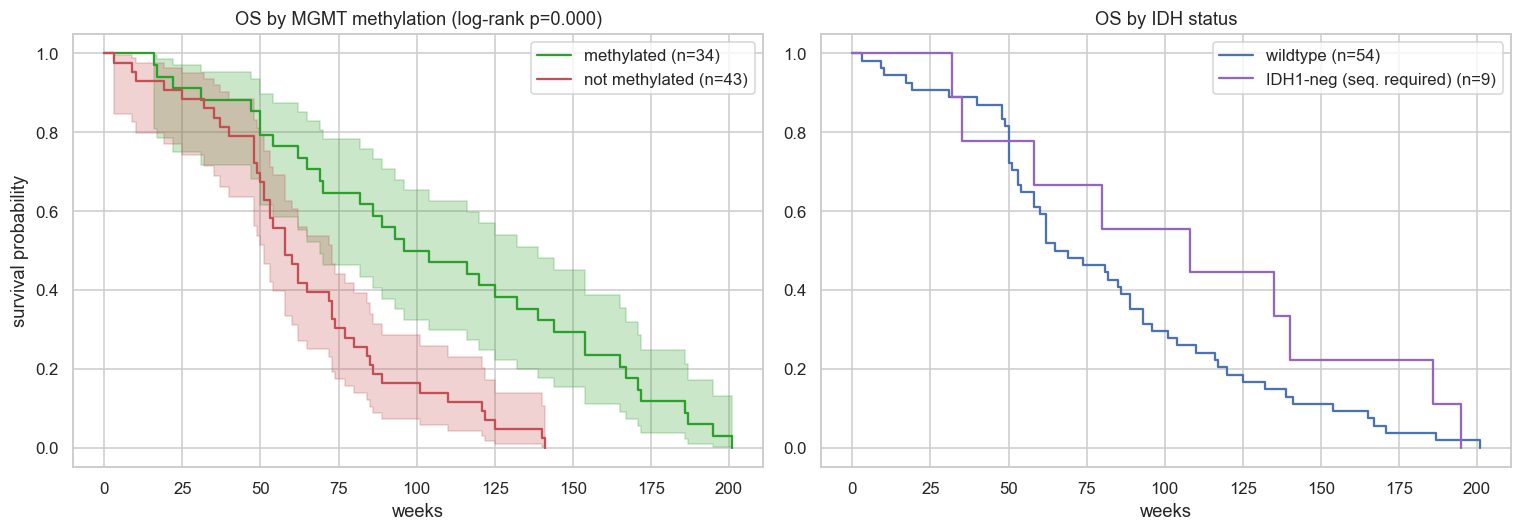

Median OS (weeks) by MGMT:
MGMT_clean
methylated        100.0
not methylated     58.0
Name: Survival_weeks, dtype: float64


In [6]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

surv = demo.dropna(subset=["Survival_weeks"]).copy()
surv["event"] = 1  # no censoring info provided (see caveat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- by MGMT ---
kmf = KaplanMeierFitter()
for grp, color in [("methylated", "#2ca02c"), ("not methylated", "#C44E52")]:
    mask = surv["MGMT_clean"] == grp
    if mask.sum():
        kmf.fit(surv.loc[mask, "Survival_weeks"], surv.loc[mask, "event"],
                label=f"{grp} (n={mask.sum()})")
        kmf.plot_survival_function(ax=axes[0], color=color, ci_show=True)
a = surv[surv["MGMT_clean"] == "methylated"]; b = surv[surv["MGMT_clean"] == "not methylated"]
if len(a) and len(b):
    p = logrank_test(a["Survival_weeks"], b["Survival_weeks"], a["event"], b["event"]).p_value
    axes[0].set_title(f"OS by MGMT methylation (log-rank p={p:.3f})")
axes[0].set_xlabel("weeks"); axes[0].set_ylabel("survival probability")

# --- by IDH ---
kmf = KaplanMeierFitter()
for grp, color in [("wildtype", "#4C72B0"), ("mutant", "#ff7f0e"), ("IDH1-neg (seq. required)", "#9467bd")]:
    mask = surv["IDH_clean"] == grp
    if mask.sum() >= 2:
        kmf.fit(surv.loc[mask, "Survival_weeks"], surv.loc[mask, "event"],
                label=f"{grp} (n={mask.sum()})")
        kmf.plot_survival_function(ax=axes[1], color=color, ci_show=False)
axes[1].set_title("OS by IDH status"); axes[1].set_xlabel("weeks")
plt.tight_layout(); plt.show()

print("Median OS (weeks) by MGMT:")
print(surv.groupby("MGMT_clean")["Survival_weeks"].median())

## M2 — Longitudinal timeline structure

A tracking pipeline lives or dies on the *temporal* structure of the data: how many scans per patient, how long the follow-up, and how irregular the spacing is.

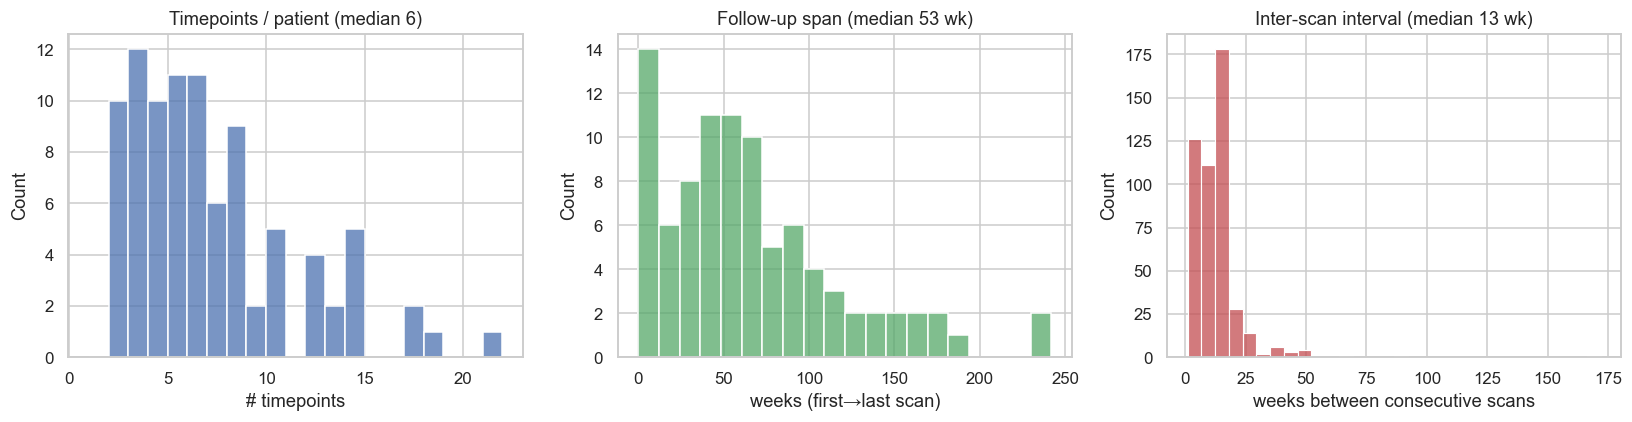

Total scans: 616 | patients: 91
Timepoints/patient: min 2, max 21
Interval weeks: median 13, IQR 6–15, max 172


In [7]:
# Per-patient longitudinal summary
g = rano.groupby("Patient")
tp_per_patient = g.size()
followup = g["week"].max() - g["week"].min()

# Inter-scan intervals (consecutive unique weeks per patient)
intervals = []
for p, sub in rano.groupby("Patient"):
    wks = sorted(sub["week"].dropna().unique())
    intervals += list(np.diff(wks))
intervals = pd.Series(intervals, name="interval_weeks")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(tp_per_patient, bins=range(1, tp_per_patient.max() + 2), ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Timepoints / patient (median {int(tp_per_patient.median())})")
axes[0].set_xlabel("# timepoints")
sns.histplot(followup, bins=20, ax=axes[1], color="#55A868")
axes[1].set_title(f"Follow-up span (median {followup.median():.0f} wk)")
axes[1].set_xlabel("weeks (first→last scan)")
sns.histplot(intervals, bins=30, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Inter-scan interval (median {intervals.median():.0f} wk)")
axes[2].set_xlabel("weeks between consecutive scans")
plt.tight_layout(); plt.show()

print(f"Total scans: {len(rano)} | patients: {rano['Patient'].nunique()}")
print(f"Timepoints/patient: min {tp_per_patient.min()}, max {tp_per_patient.max()}")
print(f"Interval weeks: median {intervals.median():.0f}, IQR "
      f"{intervals.quantile(.25):.0f}–{intervals.quantile(.75):.0f}, max {intervals.max():.0f}")

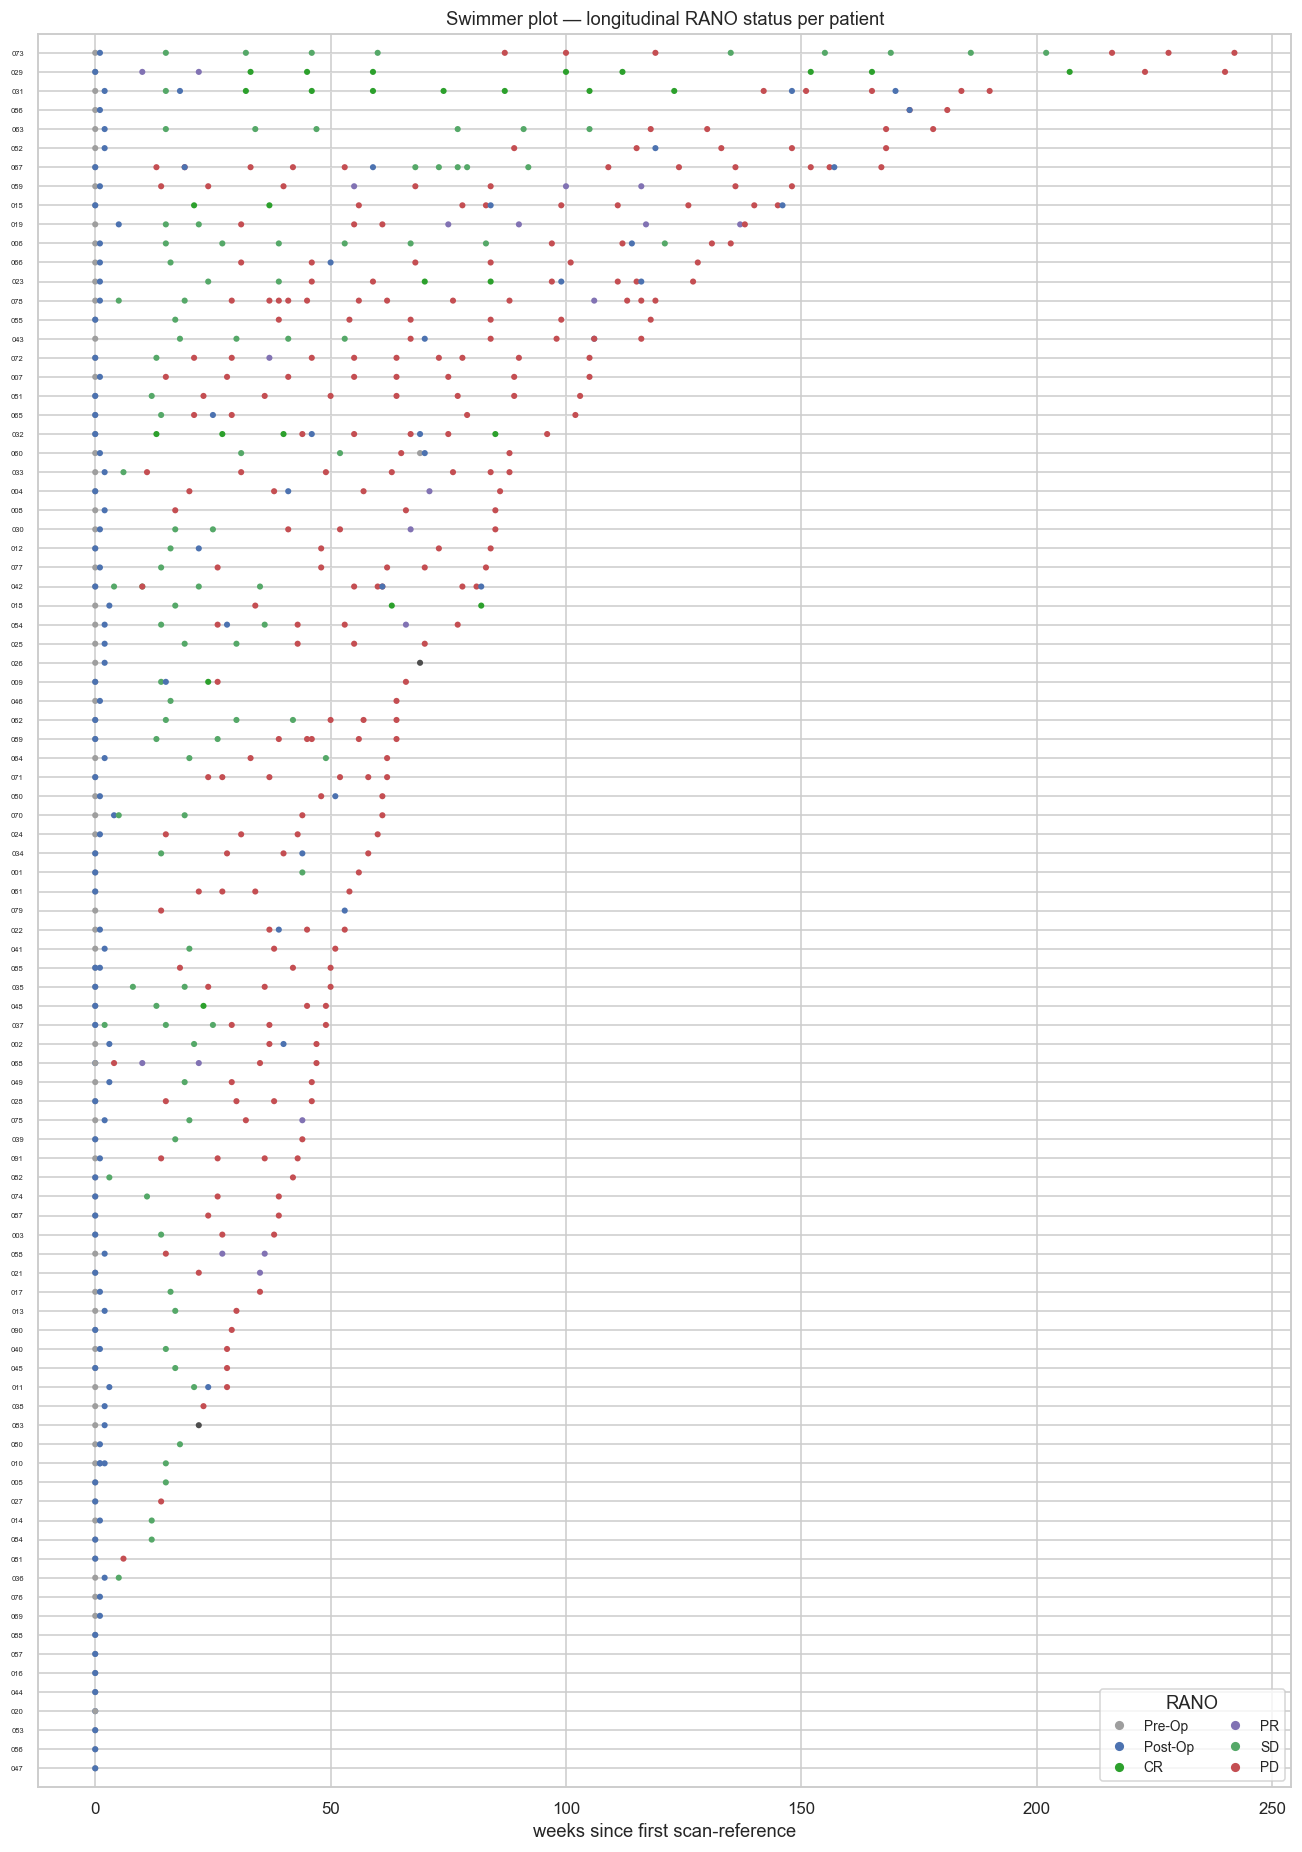

In [8]:
# Swimmer plot: one row per patient, points = scans coloured by RANO
order = g["week"].max().sort_values().index
fig, ax = plt.subplots(figsize=(12, 17))
for i, p in enumerate(order):
    sub = rano[rano["Patient"] == p].sort_values("week")
    ax.plot(sub["week"], [i] * len(sub), "-", color="0.85", lw=0.7, zorder=1)
    ax.scatter(sub["week"], [i] * len(sub),
               c=[RANO_PALETTE.get(r, "0.3") for r in sub["Rating_clean"]],
               s=16, zorder=2, edgecolor="none")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([p.replace("Patient-", "") for p in order], fontsize=5)
ax.set_ylim(-1, len(order))
ax.set_xlabel("weeks since first scan-reference")
ax.set_title("Swimmer plot — longitudinal RANO status per patient")
handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=RANO_PALETTE[k], mec="none", label=k)
           for k in RANO_ORDER]
ax.legend(handles=handles, title="RANO", loc="lower right", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

## M3 — RANO label analysis (ground truth)

The `ExpertRating` column is our supervision signal. We look at the label distribution, how patients *transition* between states, time-to-progression, and the **pseudoprogression** trap (apparent PD < 3 months after chemoradiation).

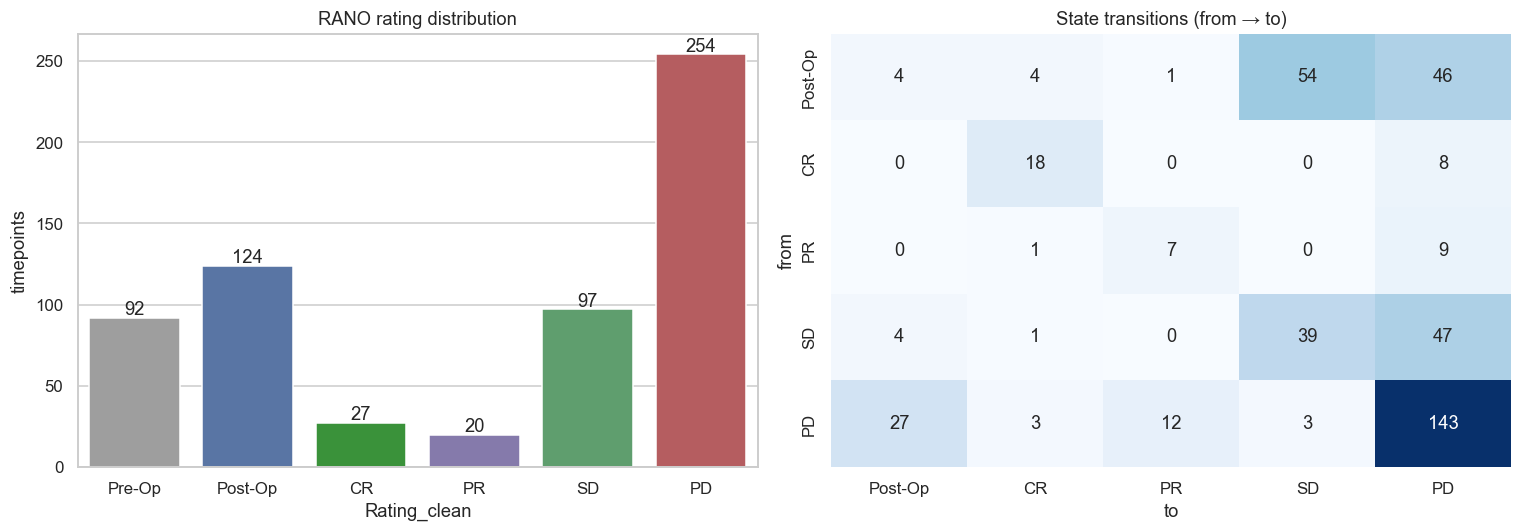

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
vc = rano["Rating_clean"].value_counts().reindex(RANO_ORDER).dropna()
sns.barplot(x=vc.index, y=vc.values, ax=axes[0],
            palette=[RANO_PALETTE[k] for k in vc.index])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2, int(v), ha="center")
axes[0].set_title("RANO rating distribution"); axes[0].set_ylabel("timepoints")

# Transition matrix over follow-up states (exclude Pre-Op)
states = ["Post-Op", "CR", "PR", "SD", "PD"]
T = pd.DataFrame(0, index=states, columns=states)
for p, sub in rano.sort_values("week").groupby("Patient"):
    seq = [s for s in sub["Rating_clean"] if s in states]
    for a, b in zip(seq[:-1], seq[1:]):
        T.loc[a, b] += 1
sns.heatmap(T, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("State transitions (from → to)")
axes[1].set_xlabel("to"); axes[1].set_ylabel("from")
plt.tight_layout(); plt.show()

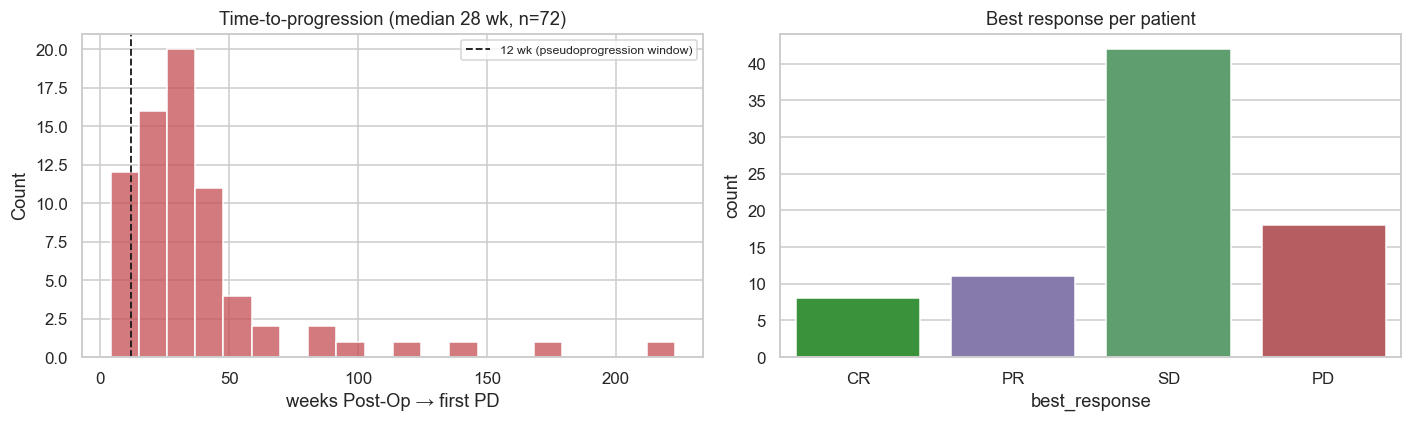

Patients ever reaching PD          : 73/91
Explicit pseudoprogression flags   : 1 timepoints, 1 patients
First PD within 12 wk of baseline  : 4 patients  <-- tracker must treat these cautiously


In [10]:
# Time-to-progression: weeks from first Post-Op (baseline) to first PD *after* that baseline
rows = []
for p, sub in rano.sort_values("week").groupby("Patient"):
    base = sub[sub["Rating_clean"] == "Post-Op"]["week"].min()
    if pd.notna(base):
        pd_wk = sub[(sub["Rating_clean"] == "PD") & (sub["week"] >= base)]["week"].min()
    else:
        pd_wk = np.nan
    best = None
    for r in ["CR", "PR", "SD", "PD"]:
        if (sub["Rating_clean"] == r).any():
            best = r; break
    rows.append({"Patient": p, "baseline_wk": base, "first_PD_wk": pd_wk,
                 "TTP_wk": (pd_wk - base) if pd.notna(base) and pd.notna(pd_wk) else np.nan,
                 "ever_PD": (sub["Rating_clean"] == "PD").any(),
                 "best_response": best})
ttp = pd.DataFrame(rows)

# Pseudoprogression risk has two views:
#   (a) explicit dataset flags: PD rated < 3 months OR discussed as "irradiated area"
#   (b) the clinical window: first PD within 12 weeks of the post-op baseline
pseudo_flag = rano[(rano["Rating_clean"] == "PD") &
                   (rano["lt3m"] | rano["Rationale"].astype(str).str.contains("irradiated", case=False))]
early_pd = ttp[ttp["TTP_wk"] < 12]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(ttp["TTP_wk"].dropna(), bins=20, ax=axes[0], color="#C44E52")
axes[0].axvline(12, ls="--", color="k", lw=1.2, label="12 wk (pseudoprogression window)")
axes[0].set_title(f"Time-to-progression (median {ttp['TTP_wk'].median():.0f} wk, "
                  f"n={ttp['TTP_wk'].notna().sum()})")
axes[0].set_xlabel("weeks Post-Op → first PD"); axes[0].legend(fontsize=8)
sns.countplot(x="best_response", data=ttp, ax=axes[1],
              order=[r for r in ["CR", "PR", "SD", "PD"] if r in ttp['best_response'].values],
              palette=RANO_PALETTE)
axes[1].set_title("Best response per patient")
plt.tight_layout(); plt.show()

print(f"Patients ever reaching PD          : {ttp['ever_PD'].sum()}/{len(ttp)}")
print(f"Explicit pseudoprogression flags   : {len(pseudo_flag)} timepoints, {pseudo_flag['Patient'].nunique()} patients")
print(f"First PD within 12 wk of baseline  : {len(early_pd)} patients  <-- tracker must treat these cautiously")

## M4 — RANO rationale text-mining

The free-text `Rationale` hides structured RANO data: the **bidimensional (Macdonald) measurements** of target lesions, resection completeness (CRET/PRET), T2/FLAIR progression, new lesions, and drug context (Avastin/Temodal). We parse it into features — in particular the **sum of products of diameters (SPD)**, the quantity RANO thresholds are defined on.

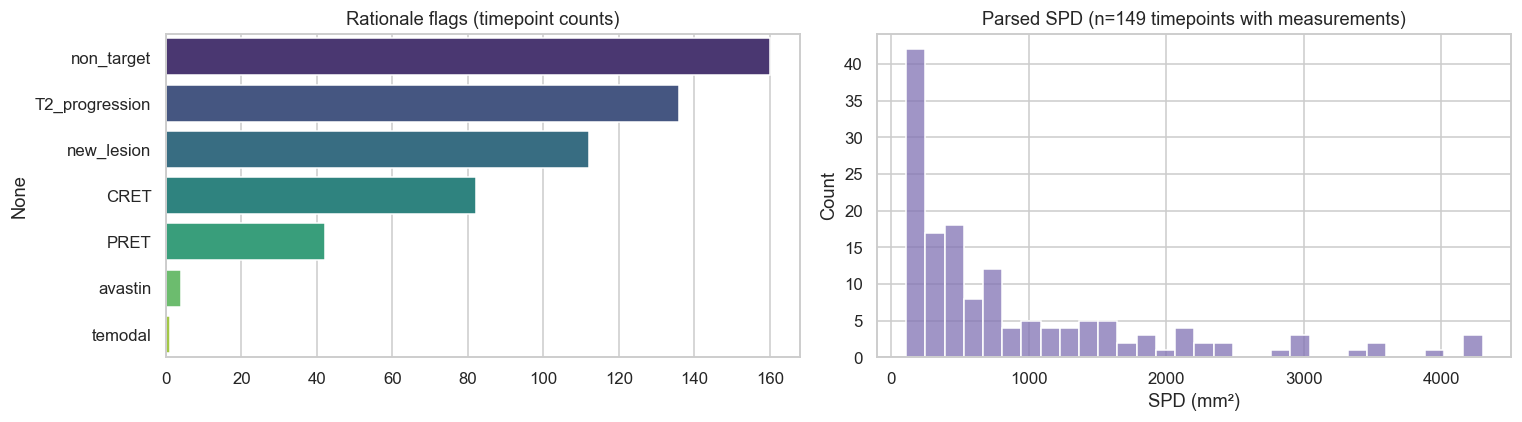

Timepoints with >=1 measurable target lesion: 149


,Patient,Date,Rating_clean,n_target_measured,SPD_mm2
3,Patient-001,week-056,PD,1,156.0
7,Patient-002,week-037,PD,1,338.0
9,Patient-002,week-047,PD,1,1232.0
14,Patient-003,week-038,PD,2,499.0
18,Patient-004,week-038,PD,1,624.0
20,Patient-004,week-057,PD,1,408.0
21,Patient-004,week-071,PR,1,240.0
22,Patient-004,week-086,PD,1,672.0


In [11]:
pair_re = re.compile(r"(\d+(?:\.\d+)?)\s*mm\s*[x×]\s*(\d+(?:\.\d+)?)\s*mm", re.I)

def parse_rationale(text):
    t = str(text)
    pairs = [(float(a), float(b)) for a, b in pair_re.findall(t)]
    spd = sum(a * b for a, b in pairs)                      # sum of products of perp. diameters
    return pd.Series({
        "n_target_measured": len(pairs),
        "SPD_mm2": spd if pairs else np.nan,
        "CRET": bool(re.search(r"\bCRET\b", t)),
        "PRET": bool(re.search(r"\bPRET\b", t)),
        "T2_progression": bool(re.search(r"T2-?Progr", t, re.I)),
        "new_lesion": bool(re.search(r"\bnew\b", t, re.I)),
        "non_target": bool(re.search(r"non-?target", t, re.I)),
        "avastin": bool(re.search(r"avastin|bevacizu", t, re.I)),
        "temodal": bool(re.search(r"temodal|temozolo", t, re.I)),
    })

parsed = rano["Rationale"].apply(parse_rationale)
rano = pd.concat([rano, parsed], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
flags = ["CRET", "PRET", "T2_progression", "new_lesion", "non_target", "avastin", "temodal"]
counts = rano[flags].sum().sort_values(ascending=False)
sns.barplot(x=counts.values, y=counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Rationale flags (timepoint counts)")
sub = rano[rano["SPD_mm2"].notna()]
sns.histplot(sub["SPD_mm2"], bins=30, ax=axes[1], color="#8172B3")
axes[1].set_title(f"Parsed SPD (n={len(sub)} timepoints with measurements)")
axes[1].set_xlabel("SPD (mm²)")
plt.tight_layout(); plt.show()

print("Timepoints with >=1 measurable target lesion:", (rano["n_target_measured"] > 0).sum())
display(rano.loc[rano["SPD_mm2"].notna(),
        ["Patient", "Date", "Rating_clean", "n_target_measured", "SPD_mm2"]].head(8))

## M5 — Imaging completeness, scanner heterogeneity & label-convention check

Three pipeline-critical checks: (1) which sequences/segmentations exist per scan, (2) how heterogeneous the acquisition is (field strength / vendor / slice thickness → harmonisation risk), and (3) verifying the **segmentation label convention**, because the raw mask integers do **not** match the radiomics-table integers.

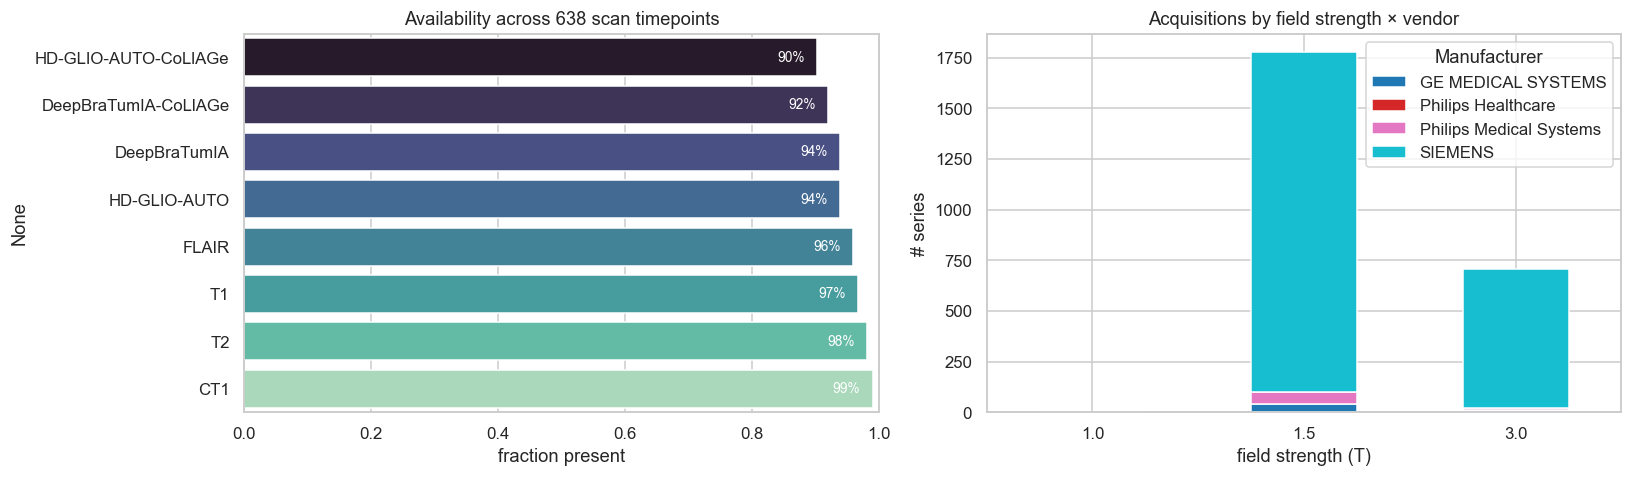

RANO-rated timepoints: 613 | with DeepBraTumIA radiomics: 560 | rated but UN-segmented: 53
Slice thickness (mm): median 3.0, range 0.8–6.0


In [12]:
# --- Completeness ---
avail_cols = ["CT1", "T1", "T2", "FLAIR", "DeepBraTumIA", "HD-GLIO-AUTO",
              "DeepBraTumIA-CoLlAGe", "HD-GLIO-AUTO-CoLlAGe"]
comp = complete.copy()
for c in avail_cols:
    comp[c] = comp[c].astype(str).str.strip().eq("x").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
frac = comp[avail_cols].mean().sort_values()
sns.barplot(x=frac.values, y=frac.index, ax=axes[0], palette="mako")
axes[0].set_title(f"Availability across {len(comp)} scan timepoints")
axes[0].set_xlabel("fraction present"); axes[0].set_xlim(0, 1)
for i, v in enumerate(frac.values):
    axes[0].text(v - 0.02, i, f"{v*100:.0f}%", va="center", ha="right", color="white", fontsize=9)

# --- Scanner heterogeneity ---
mr = mrinfo.copy()
mr["Manufacturer"] = mr["Manufacturer"].astype(str).str.strip()
mr["Field strength"] = pd.to_numeric(mr["Field strength"], errors="coerce")
cross = mr.groupby(["Field strength", "Manufacturer"]).size().unstack(fill_value=0)
cross.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab10")
axes[1].set_title("Acquisitions by field strength × vendor")
axes[1].set_xlabel("field strength (T)"); axes[1].set_ylabel("# series")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

# Rated-but-unsegmented
rk = set(zip(rano["Patient"], rano["Date"]))
rr = set(zip(rad_dbt["Patient"], rad_dbt["Time point"]))
print(f"RANO-rated timepoints: {len(rk)} | with DeepBraTumIA radiomics: {len(rk & rr)} | "
      f"rated but UN-segmented: {len(rk - rr)}")
print("Slice thickness (mm):",
      f"median {mr['Slice thickness'].median():.1f}, "
      f"range {mr['Slice thickness'].min():.1f}–{mr['Slice thickness'].max():.1f}")

In [13]:
# --- Label-convention check: match mask integers to the volume JSON across several patients ---
JSON_KEY = {"Enhancing_Core": "Enhancing", "Necrotic_NonEnhancing": "Necrosis", "Edema_Compartment": "Edema"}

def infer_label_map(patient, tp):
    "Return {mask_integer: tissue} by matching voxel counts to measured_volumes JSON."
    j = load_json_from_zip(m_dbt_vol(patient, tp))
    mask = np.asanyarray(load_nifti_from_zip(m_dbt_mask(patient, tp)).dataobj).astype(int)
    counts = {int(l): int((mask == l).sum()) for l in np.unique(mask) if l > 0}
    out, used = {}, set()
    for lab, cnt in counts.items():
        cand = [(k, v) for k, v in j.items() if k not in used]
        best = min(cand, key=lambda kv: abs(kv[1] - cnt))
        out[lab] = JSON_KEY.get(best[0], best[0]); used.add(best[0])
    return out

sample = (rad_dbt[["Patient", "Time point"]].drop_duplicates().head(6).values.tolist())
print("DeepBraTumIA atlas seg_mask.nii.gz integer -> tissue (from JSON matching):")
for pt, tp in sample:
    if m_dbt_mask(pt, tp) in ZIP_MEMBERS:
        print(f"  {pt} {tp}: {infer_label_map(pt, tp)}")
print("\nRadiomics CSV 'Label name' vs 'Label' integer (DeepBraTumIA):")
print(rad_dbt[["Label name", "Label"]].drop_duplicates().to_string(index=False))
print("\n=> Use the 'Label name' STRING for volumetrics; the mask integers follow a different convention.")

DeepBraTumIA atlas seg_mask.nii.gz integer -> tissue (from JSON matching):
  Patient-001 week-000-1: {1: 'Enhancing', 2: 'Necrosis', 3: 'Edema'}
  Patient-001 week-000-2: {1: 'Enhancing', 2: 'Necrosis', 3: 'Edema'}
  Patient-001 week-044: {1: 'Enhancing', 2: 'Necrosis', 3: 'Edema'}
  Patient-001 week-056: {1: 'Enhancing', 3: 'Edema'}
  Patient-002 week-000: {1: 'Enhancing', 2: 'Necrosis', 3: 'Edema'}
  Patient-002 week-003: {1: 'Enhancing', 2: 'Necrosis', 3: 'Edema'}

Radiomics CSV 'Label name' vs 'Label' integer (DeepBraTumIA):
        Label name  Label
          Necrosis      1
Contrast-enhancing      2
             Edema      3

=> Use the 'Label name' STRING for volumetrics; the mask integers follow a different convention.


In [ ]:
# --- Schema verification: unique mask integers == documented set, BOTH sources, >=2 patients ---
# Backs the label_schema.py deliverable (integers triangulated from the pyradiomics CSVs +
# measured_volumes JSON + tool papers; here we confirm real masks match, no off-schema labels).
from label_schema import LABEL_SCHEMA, DEEPBRATUMIA_LABELS, HDGLIO_LABELS

DOC = {"DeepBraTumIA": set(DEEPBRATUMIA_LABELS), "HD-GLIO-AUTO": set(HDGLIO_LABELS)}
mask_path = {"DeepBraTumIA": m_dbt_mask, "HD-GLIO-AUTO": m_hdg_mask}

check_pts = (rad_dbt.groupby("Patient")["Time point"].first().head(3)  # >=2 distinct patients
              .reset_index().values.tolist())
for src in ("DeepBraTumIA", "HD-GLIO-AUTO"):
    print(f"{src}  documented integers = {sorted(DOC[src])}")
    for pat, tp in check_pts:
        mem = mask_path[src](pat, tp)
        if mem not in ZIP_MEMBERS:
            continue
        img = load_nifti_from_zip(mem)
        d = np.asanyarray(img.dataobj).astype(int)
        vox = float(np.prod(img.header.get_zooms()[:3]))
        vals, cnts = np.unique(d, return_counts=True)
        found = {int(v) for v in vals}
        status = "OK" if found.issubset(DOC[src]) else "!!! OFF-SCHEMA"
        vols = {LABEL_SCHEMA[src][int(v)]: round(int(c) * vox) for v, c in zip(vals, cnts) if v > 0}
        print(f"   {pat} {tp}: integers={sorted(found)} [{status}]  mm3={vols}")
    print()


## M6 — Segmentation-derived volumetrics

We turn the radiomics tables into **per-compartment volumes per timepoint** (shape features are mask-only, so identical across sequences — we take the CT1 rows). These volume trajectories are the backbone of any tracking pipeline; we check whether the **enhancing-tumour volume** moves the way the expert RANO call says it should.

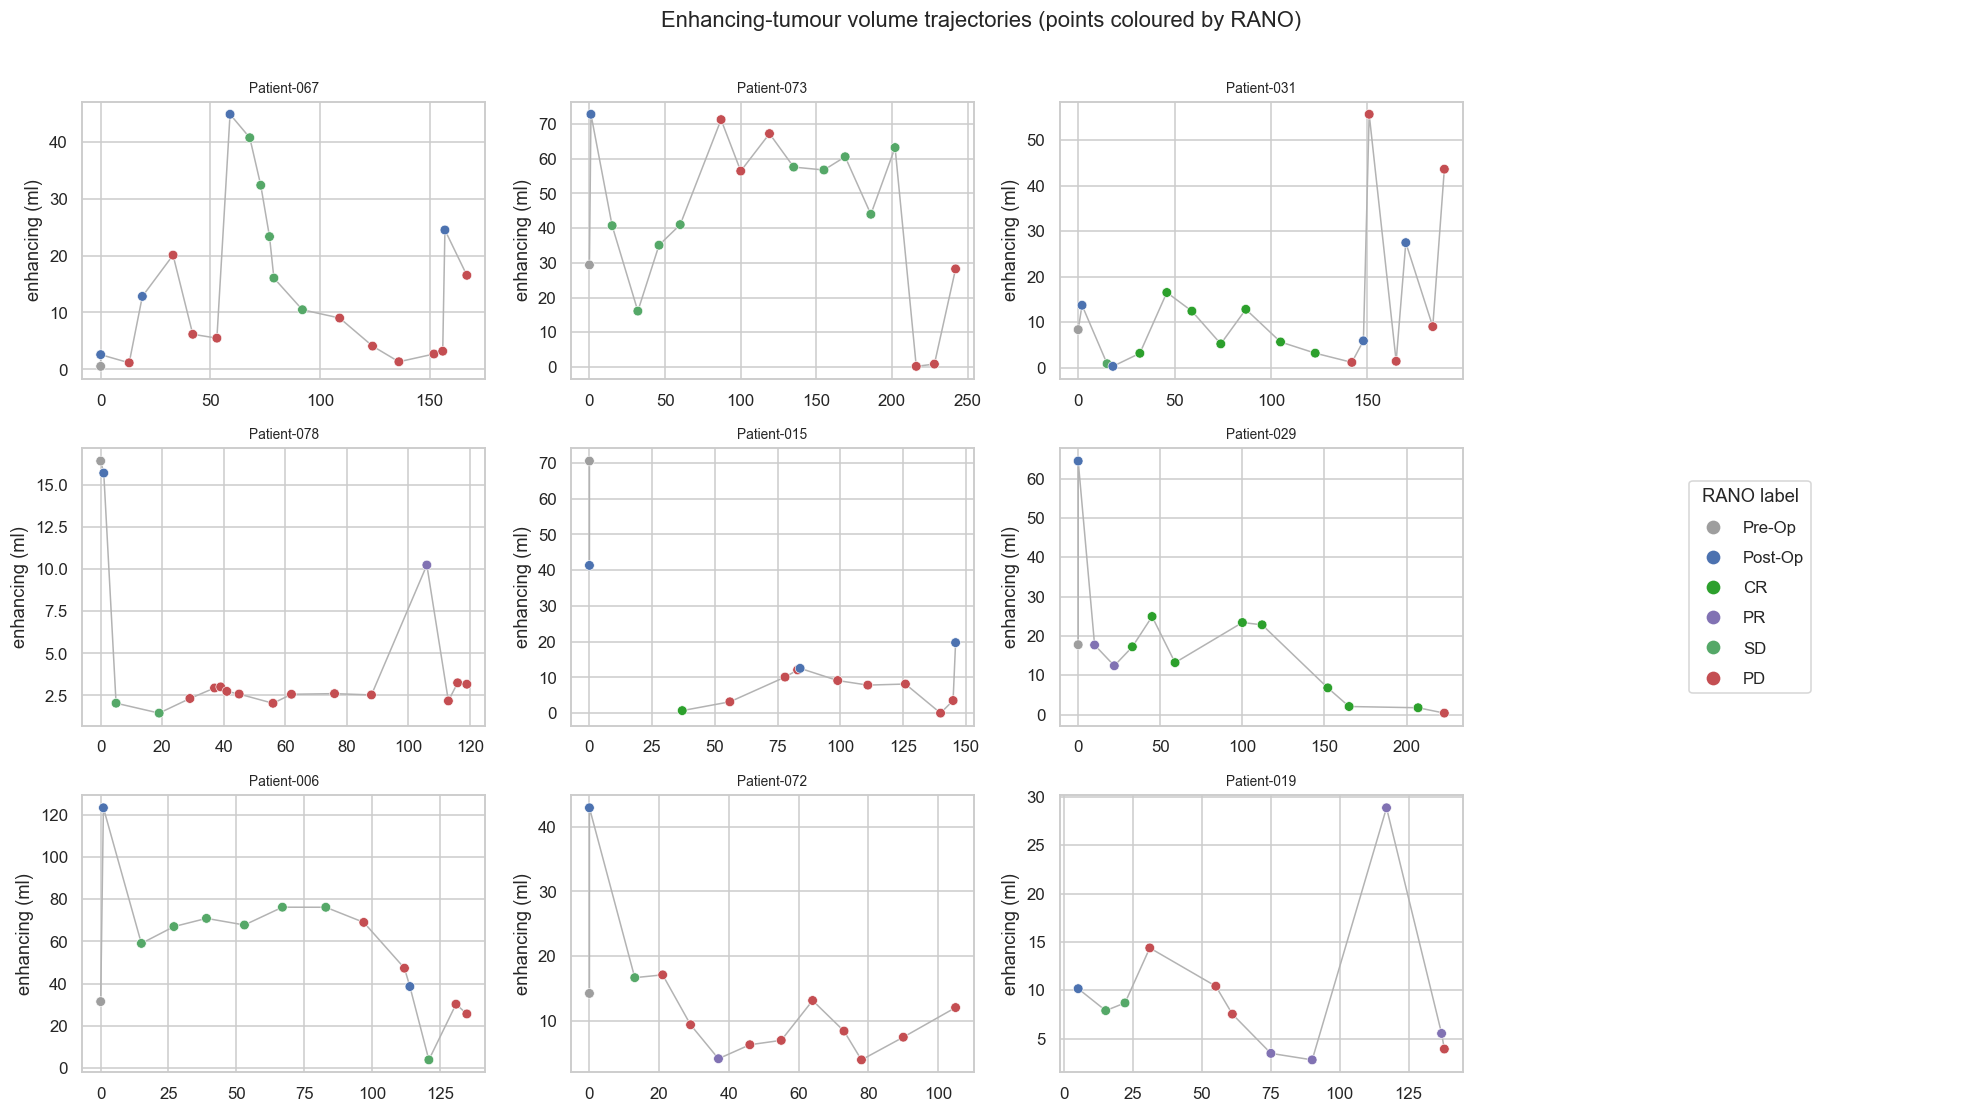

In [14]:
def volume_table(rad, method):
    sub = rad[rad["Sequence"] == "CT1"][["Patient", "Time point", "Label name",
                                          "original_shape_VoxelVolume"]].copy()
    piv = (sub.pivot_table(index=["Patient", "Time point"], columns="Label name",
                           values="original_shape_VoxelVolume", aggfunc="first")
              .reset_index().rename(columns={"Time point": "Date"}))
    piv.columns.name = None
    piv["method"] = method
    return piv

vol_dbt = volume_table(rad_dbt, "DeepBraTumIA")   # Contrast-enhancing, Edema, Necrosis
vol_hdg = volume_table(rad_hdg, "HD-GLIO-AUTO")   # Contrast-enhancing, Non-enhancing

key = rano[["Patient", "Date", "week", "Rating_clean"]]
vdbt = vol_dbt.merge(key, on=["Patient", "Date"], how="left")
vdbt["enh_ml"] = vdbt["Contrast-enhancing"] / 1000.0   # mm^3 -> cm^3 (ml)

top = vol_dbt["Patient"].value_counts().head(9).index

# 3×4 grid: first 3 columns = 9 patient panels, 4th column (middle row) = legend
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=False)
data_axes = [axes[r, c] for r in range(3) for c in range(3)]

for ax, p in zip(data_axes, top):
    s = vdbt[vdbt["Patient"] == p].sort_values("week")
    ax.plot(s["week"], s["enh_ml"], "-", color="0.7", lw=1, zorder=1)
    ax.scatter(s["week"], s["enh_ml"],
               c=[RANO_PALETTE.get(r, "0.3") for r in s["Rating_clean"]],
               s=40, zorder=2, edgecolors="white", linewidths=0.4)
    ax.set_title(p, fontsize=9)
    ax.set_ylabel("enhancing (ml)")

# blank out the three right-column cells that aren't the legend
for r in [0, 2]:
    axes[r, 3].set_visible(False)

# legend lives in its own dedicated blank panel — can't overlap any data
legend_ax = axes[1, 3]
legend_ax.axis("off")
legend_states = [r for r in RANO_ORDER if r in vdbt["Rating_clean"].dropna().unique()]
legend_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", markersize=9,
               markerfacecolor=RANO_PALETTE[r], markeredgecolor="none", label=r)
    for r in legend_states
]
legend_ax.legend(legend_handles, legend_states,
                 title="RANO label", loc="center",
                 frameon=True, fontsize=11, title_fontsize=12,
                 handletextpad=0.8, labelspacing=0.9)

fig.suptitle("Enhancing-tumour volume trajectories (points coloured by RANO)", y=1.01)
plt.tight_layout()
plt.show()

### M6b — Enhancing vs non-enhancing (FLAIR / edema) volume

The enhancing-only view (above) misses progressions driven by the **non-enhancing / T2-FLAIR** compartment. Overlaying both compartments makes those cases obvious: when the enhancing line falls but the **edema (▲, dashed)** line climbs into a **PD** point, the progression was T2/FLAIR-driven — e.g. Patient-067 around week 109.


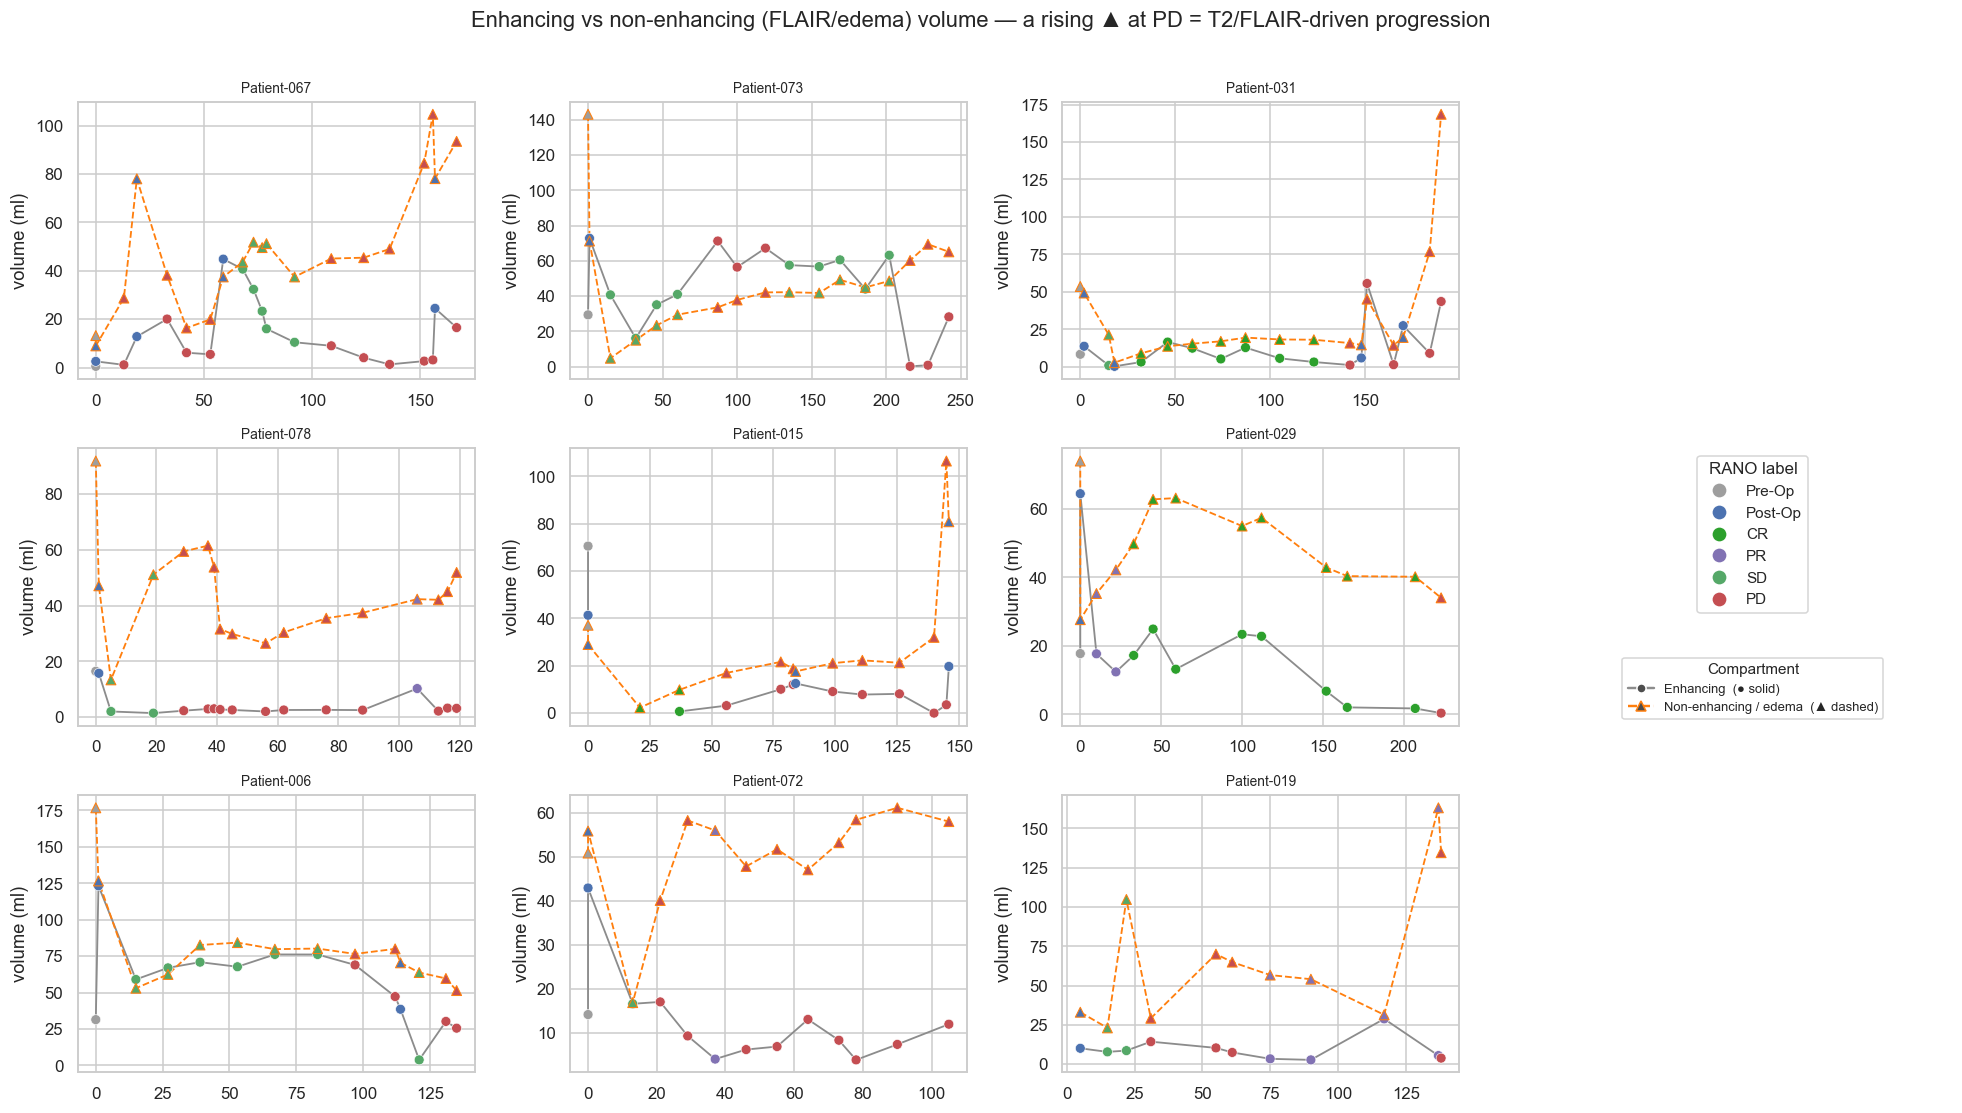

In [15]:
# Enhancing vs NON-enhancing (FLAIR / edema) volume — reveals what triggers PD.
# DeepBraTumIA compartments: "Contrast-enhancing" (enhancing) and "Edema" (T2/FLAIR non-enhancing disease).
vdbt2 = vol_dbt.merge(rano[["Patient", "Date", "week", "Rating_clean"]], on=["Patient", "Date"], how="left")
vdbt2["enh_ml"]   = vdbt2["Contrast-enhancing"] / 1000.0
vdbt2["edema_ml"] = vdbt2["Edema"] / 1000.0

top = vol_dbt["Patient"].value_counts().head(9).index

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=False)
data_axes = [axes[r, c] for r in range(3) for c in range(3)]

for ax, p in zip(data_axes, top):
    s = vdbt2[vdbt2["Patient"] == p].sort_values("week")
    # Enhancing: solid grey line, markers coloured by RANO
    ax.plot(s["week"], s["enh_ml"], "-", color="0.55", lw=1.2, zorder=1)
    ax.scatter(s["week"], s["enh_ml"],
               c=[RANO_PALETTE.get(r, "0.3") for r in s["Rating_clean"]],
               s=42, zorder=3, edgecolors="white", linewidths=0.4)
    # Non-enhancing / edema: dashed orange line, triangle markers coloured by RANO
    ax.plot(s["week"], s["edema_ml"], "--", color="#ff7f0e", lw=1.2, zorder=1)
    ax.scatter(s["week"], s["edema_ml"],
               c=[RANO_PALETTE.get(r, "0.3") for r in s["Rating_clean"]],
               s=42, marker="^", zorder=3, edgecolors="#ff7f0e", linewidths=0.7)
    ax.set_title(p, fontsize=9)
    ax.set_ylabel("volume (ml)")

for r in [0, 2]:
    axes[r, 3].set_visible(False)

legend_ax = axes[1, 3]
legend_ax.axis("off")
legend_states = [r for r in RANO_ORDER if r in vdbt2["Rating_clean"].dropna().unique()]
rano_handles = [plt.Line2D([0], [0], marker="o", linestyle="", markersize=9,
                markerfacecolor=RANO_PALETTE[r], markeredgecolor="none", label=r)
                for r in legend_states]
style_handles = [
    plt.Line2D([0], [0], color="0.55", lw=1.6, marker="o", markerfacecolor="0.3",
               markeredgecolor="white", label="Enhancing  (● solid)"),
    plt.Line2D([0], [0], color="#ff7f0e", lw=1.6, ls="--", marker="^", markerfacecolor="0.3",
               markeredgecolor="#ff7f0e", label="Non-enhancing / edema  (▲ dashed)"),
]
leg1 = legend_ax.legend(rano_handles, legend_states, title="RANO label",
                        loc="upper center", frameon=True, fontsize=10, title_fontsize=11)
legend_ax.add_artist(leg1)
legend_ax.legend(handles=style_handles, title="Compartment",
                 loc="lower center", frameon=True, fontsize=8.5, title_fontsize=10)

fig.suptitle("Enhancing vs non-enhancing (FLAIR/edema) volume — a rising ▲ at PD = T2/FLAIR-driven progression", y=1.01)
plt.tight_layout()
plt.show()

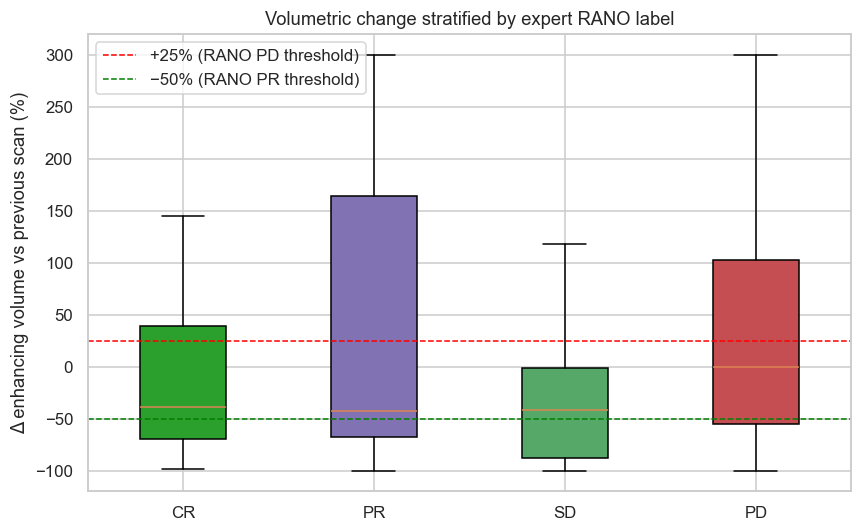

Rating_clean
CR   -38.991315
PR   -42.625546
SD   -41.251623
PD     0.000000
Name: enh_pct_change, dtype: float64


In [16]:
# Does enhancing-volume %-change agree with the expert call?
vdbt = vdbt.sort_values(["Patient", "week"])
vdbt["enh_pct_change"] = vdbt.groupby("Patient")["enh_ml"].pct_change() * 100

fig, ax = plt.subplots(figsize=(8, 5))
cats = [c for c in ["CR", "PR", "SD", "PD"] if c in vdbt["Rating_clean"].unique()]
data = [vdbt.loc[vdbt["Rating_clean"] == c, "enh_pct_change"].dropna().clip(-100, 300) for c in cats]
bp = ax.boxplot(data, tick_labels=cats, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], cats):
    patch.set_facecolor(RANO_PALETTE[c])
ax.axhline(25, ls="--", color="red", lw=1, label="+25% (RANO PD threshold)")
ax.axhline(-50, ls="--", color="green", lw=1, label="−50% (RANO PR threshold)")
ax.set_ylabel("Δ enhancing volume vs previous scan (%)")
ax.set_title("Volumetric change stratified by expert RANO label")
ax.legend(); plt.tight_layout(); plt.show()

print(vdbt.groupby("Rating_clean")["enh_pct_change"].median().reindex(cats))

## M6c — Can the *provided* volumes reproduce the expert RANO call?

Before building our own segmenter, we test a blunt question: if we take DeepBraTumIA's
**enhancing-tumour volume** (the canonical `measured_volumes_in_mm3.json`) and apply a simple
*volumetric-RANO* rule, how often does it match the neuroradiologist's PD/SD/PR/CR?

RANO is a **relative** judgement, so each response timepoint is scored against a reference:

- **baseline** = enhancing volume at the last **Post-Op** scan (post-treatment reference)
- **nadir**    = smallest enhancing volume seen so far (progression is measured from the low-point)

Simple rule (progression priority): `CR` if enhancing == 0 · `PD` if ≥ +40 % vs nadir ·
`PR` if ≤ −65 % vs baseline · else `SD`.

> Volumes come from the **JSONs** (not pyradiomics `vol_dbt`) on purpose: pyradiomics *omits*
> empty labels, so a complete-response scan with zero enhancing has no row — the JSON stores an
> explicit `0`, which we need for the `CR` test.

In [17]:
# --- Build DeepBraTumIA enhancing/edema/necrosis volumes from the canonical JSONs ---
recs = []
for pat, tp in rano[["Patient", "Date"]].drop_duplicates().itertuples(index=False):
    mem = m_dbt_vol(pat, tp)
    if mem not in ZIP_MEMBERS:
        continue
    d = load_json_from_zip(mem)
    recs.append(dict(Patient=pat, Date=tp,
                     enh=d.get("Enhancing_Core", 0.0),
                     nec=d.get("Necrotic_NonEnhancing", 0.0),
                     edema=d.get("Edema_Compartment", 0.0)))
vol_json = pd.DataFrame(recs)
print("DeepBraTumIA volume JSONs loaded:", len(vol_json))

# --- Apply the longitudinal baseline/nadir rule, per patient ---
RESP = ["CR", "PR", "SD", "PD"]
J = vol_json.merge(rano[["Patient", "Date", "week", "subtp", "Rating_clean", "Rationale", "nonmeas"]],
                   on=["Patient", "Date"], how="left")
J["order"] = J["week"].fillna(0) * 10 + J["subtp"].fillna(0)

rows = []
for pat, g in J.sort_values("order").groupby("Patient"):
    g = g.sort_values("order")
    postop = g[(g["Rating_clean"] == "Post-Op") & g["enh"].notna()]
    if len(postop):
        baseline = postop.iloc[-1]["enh"]
    else:
        fv = g[g["enh"].notna()]
        baseline = fv.iloc[0]["enh"] if len(fv) else np.nan
    nadir = baseline
    for _, r in g.iterrows():
        v = r["enh"]
        if r["Rating_clean"] in RESP and pd.notna(v) and pd.notna(baseline):
            pct_base  = (v - baseline) / baseline * 100 if baseline > 0 else np.nan
            pct_nadir = (v - nadir)   / nadir   * 100 if nadir   > 0 else np.nan
            if   v == 0:                                  pred = "CR"
            elif nadir > 0    and v >= 1.40 * nadir:      pred = "PD"
            elif baseline > 0 and v <= 0.35 * baseline:   pred = "PR"
            else:                                         pred = "SD"
            rows.append(dict(Patient=pat, Date=r["Date"], expert=r["Rating_clean"],
                             enh=v, baseline=baseline, nadir=nadir,
                             pct_vs_base=pct_base, pct_vs_nadir=pct_nadir, pred=pred,
                             Rationale=r["Rationale"], nonmeas=r["nonmeas"]))
        if pd.notna(v):
            nadir = min(nadir, v)
rule_res = pd.DataFrame(rows)

cm  = pd.crosstab(rule_res["expert"], rule_res["pred"]).reindex(index=RESP, columns=RESP).fillna(0).astype(int)
acc = (rule_res["expert"] == rule_res["pred"]).mean()
print("Evaluable response timepoints:", len(rule_res), "| overall accuracy:", f"{acc:.1%}")
print("\nConfusion matrix (rows = expert, cols = rule):")
print(cm)

DeepBraTumIA volume JSONs loaded: 566
Evaluable response timepoints: 379 | overall accuracy: 42.2%

Confusion matrix (rows = expert, cols = rule):
pred    CR  PR  SD   PD
expert                 
CR      15   7   0    4
PR       0   6   5    9
SD      30  11  12   41
PD      18  23  71  127


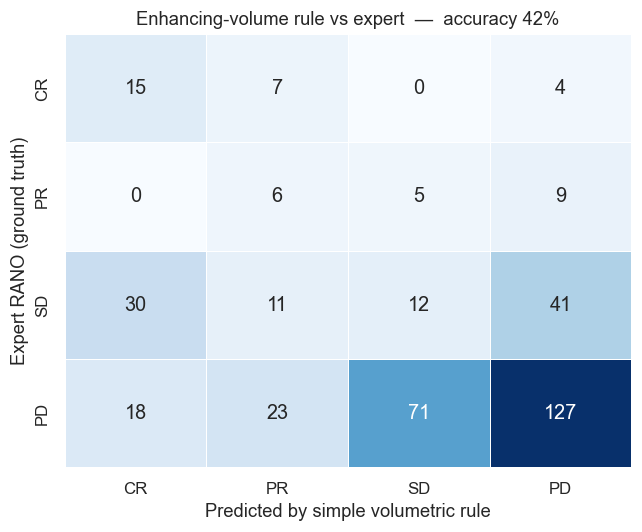

PD detection:  recall = 53.1%   precision = 70.2%   (TP=127  FP=54  FN=112  TN=86)

Takeaway: the extremes work, but a single-compartment / single-timepoint rule reproduces the expert only ~42% of the time — that gap is the finding.


In [18]:
# --- Confusion matrix + the clinically important metric: PD detection ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            annot_kws={"size": 13}, linewidths=0.5, linecolor="white")
ax.set_xlabel("Predicted by simple volumetric rule")
ax.set_ylabel("Expert RANO (ground truth)")
ax.set_title(f"Enhancing-volume rule vs expert  —  accuracy {acc:.0%}")
plt.tight_layout(); plt.show()

# PD as a binary problem (progression vs not) — the call that matters most
r = rule_res
tp = ((r.expert == "PD") & (r.pred == "PD")).sum()
fp = ((r.expert != "PD") & (r.pred == "PD")).sum()
fn = ((r.expert == "PD") & (r.pred != "PD")).sum()
tn = ((r.expert != "PD") & (r.pred != "PD")).sum()
print(f"PD detection:  recall = {tp/(tp+fn):.1%}   precision = {tp/(tp+fp):.1%}   "
      f"(TP={tp}  FP={fp}  FN={fn}  TN={tn})")
print("\nTakeaway: the extremes work, but a single-compartment / single-timepoint rule "
      "reproduces the expert only ~42% of the time — that gap is the finding.")

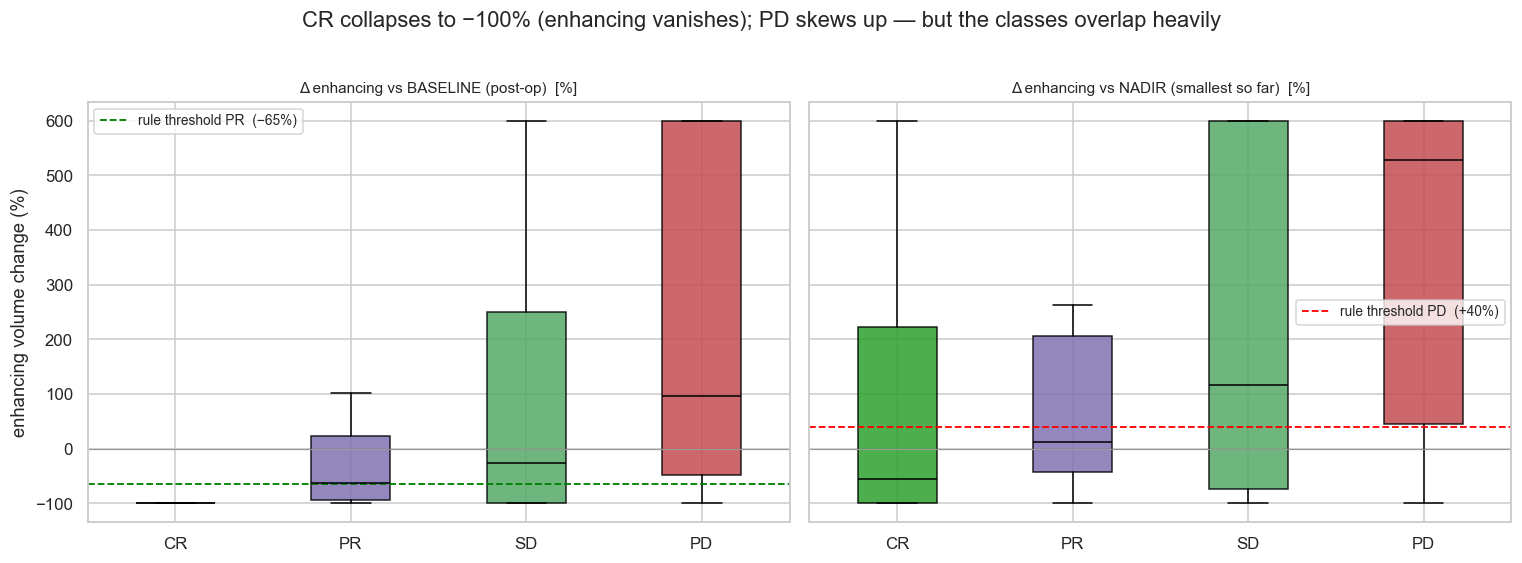

In [19]:
# --- Does enhancing %-change separate the expert classes at all? (threshold-free view) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
panels = [("pct_vs_base",  -65, "PR  (−65%)", "green", "Δ enhancing vs BASELINE (post-op)  [%]"),
          ("pct_vs_nadir",  40, "PD  (+40%)", "red",   "Δ enhancing vs NADIR (smallest so far)  [%]")]
for ax, (col, thr, lab, tc, xlab) in zip(axes, panels):
    data = [rule_res.loc[rule_res.expert == c, col].dropna().clip(-100, 600) for c in RESP]
    bp = ax.boxplot(data, tick_labels=RESP, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], RESP):
        patch.set_facecolor(RANO_PALETTE[c]); patch.set_alpha(0.85)
    for med in bp["medians"]:
        med.set_color("black")
    ax.axhline(thr, ls="--", color=tc, lw=1.2, label=f"rule threshold {lab}")
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_title(xlab, fontsize=10); ax.legend(fontsize=9)
axes[0].set_ylabel("enhancing volume change (%)")
fig.suptitle("CR collapses to −100% (enhancing vanishes); PD skews up — but the classes overlap heavily", y=1.02)
plt.tight_layout(); plt.show()

### M6c-ii — Why the enhancing-only rule misses PD: new lesions & T2/FLAIR progression

The rule missed a large share of PDs. If those misses are **not random** but instead correspond to
progression the enhancing core *cannot* show — new lesions and T2/FLAIR growth — then the ~42 % is a
*modelling* ceiling, not a data defect, and it tells us exactly which extra components the pipeline needs.
We test this against the experts' own free-text rationale.

In [ ]:
# --- Diagnose the missed PDs from the expert rationale text ---
miss = rule_res[(rule_res.expert == "PD") & (rule_res.pred != "PD")].copy()
t = miss["Rationale"].fillna("").str.lower()
reasons = {
    "New lesion":        t.str.contains("new").sum(),
    "T2/FLAIR progr.":   t.str.contains("t2|flair").sum(),
    "Non-measurable L.": miss["nonmeas"].fillna(False).astype(bool).sum(),
    "Re-resection":      t.str.contains("resect").sum(),
}
explained = t.str.contains("new|t2|flair").sum()
print(f"PDs missed by the enhancing-volume rule: {len(miss)}")
print(f"  ...explained by new lesion OR T2/FLAIR progression: {explained} ({explained/len(miss):.0%})")

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = list(reasons.keys()); vals = list(reasons.values())
bars = ax.barh(labels, vals, color=["#C44E52", "#ff7f0e", "#4C72B0", "#9e9e9e"])
ax.bar_label(bars, padding=3)
ax.set_xlabel("count among missed-PD timepoints (categories overlap)")
ax.set_title(f"Why {len(miss)} PDs are invisible to an enhancing-volume threshold")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

print("\nConclusion: the missing components are (1) T2/FLAIR non-enhancing volume, "
      "(2) new-lesion detection (needs registration), (3) baseline/nadir + confirmation logic.")

## M7 — 2D (Macdonald/RANO) vs 3D (volumetric)

RANO thresholds are defined on a **2D** bidimensional product, but a segmentation pipeline naturally produces a **3D volume**. How well do they agree? This decides whether the pipeline should track 2D SPD, 3D volume, or both.

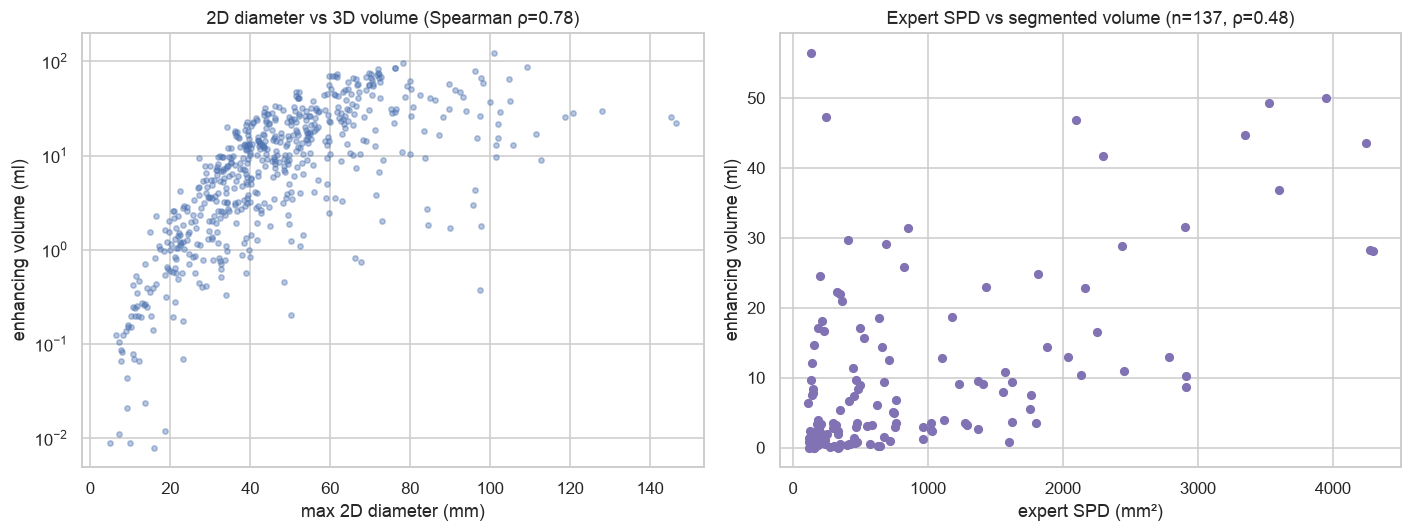

In [19]:
enh = rad_dbt[(rad_dbt["Sequence"] == "CT1") &
              (rad_dbt["Label name"] == "Contrast-enhancing")].copy()
enh["vol_ml"] = enh["original_shape_VoxelVolume"] / 1000.0
enh["diam2d"] = enh["original_shape_Maximum2DDiameterSlice"]
enh = enh[(enh["vol_ml"] > 0) & (enh["diam2d"] > 0)]

from scipy.stats import spearmanr
r_spear = spearmanr(enh["diam2d"], enh["vol_ml"]).correlation

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(enh["diam2d"], enh["vol_ml"], s=12, alpha=0.4, color="#4C72B0")
axes[0].set_xlabel("max 2D diameter (mm)"); axes[0].set_ylabel("enhancing volume (ml)")
axes[0].set_title(f"2D diameter vs 3D volume (Spearman ρ={r_spear:.2f})")
axes[0].set_yscale("log")

# Parsed SPD (M4) vs volume, merged on timepoint
spd = rano.loc[rano["SPD_mm2"].notna(), ["Patient", "Date", "SPD_mm2"]]
mg = spd.merge(enh[["Patient", "Time point", "vol_ml"]].rename(columns={"Time point": "Date"}),
               on=["Patient", "Date"], how="inner")
if len(mg) > 3:
    rr = spearmanr(mg["SPD_mm2"], mg["vol_ml"]).correlation
    axes[1].scatter(mg["SPD_mm2"], mg["vol_ml"], s=25, color="#8172B3")
    axes[1].set_title(f"Expert SPD vs segmented volume (n={len(mg)}, ρ={rr:.2f})")
else:
    axes[1].set_title("Expert SPD vs segmented volume (too few overlaps)")
axes[1].set_xlabel("expert SPD (mm²)"); axes[1].set_ylabel("enhancing volume (ml)")
plt.tight_layout(); plt.show()

## M8 — Inter-method agreement (DeepBraTumIA vs HD-GLIO-AUTO)

The pipeline will depend on an automated segmenter. How much do the two provided methods agree on the single most RANO-relevant quantity — **enhancing-tumour volume**? We use a correlation plot and a Bland–Altman plot.

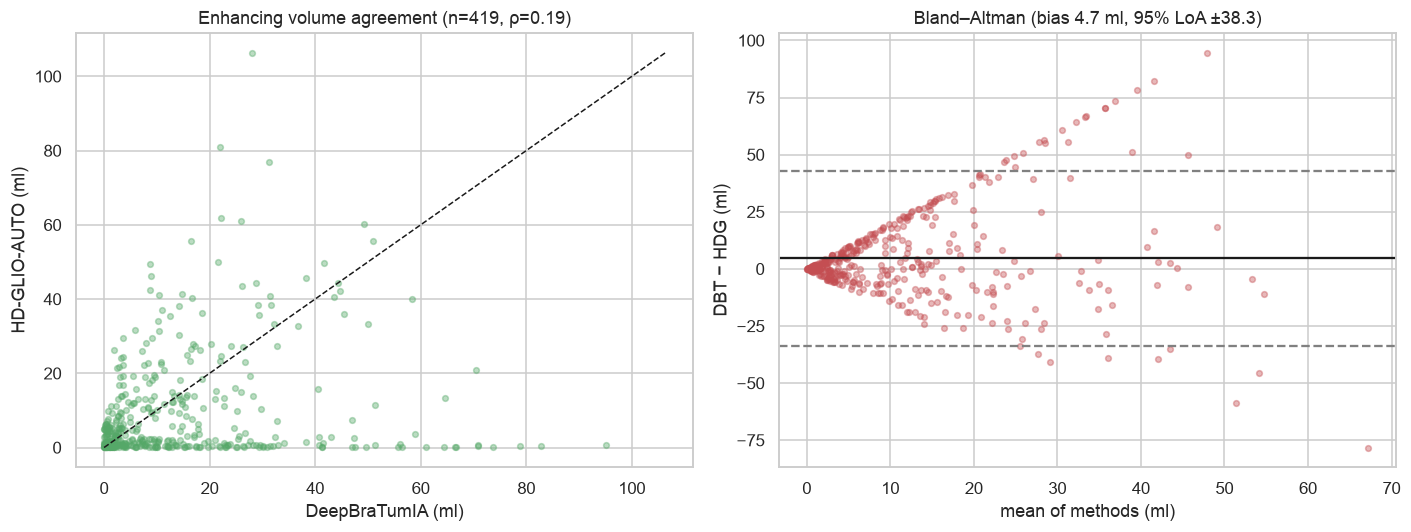

In [20]:
cmp = (vol_dbt[["Patient", "Date", "Contrast-enhancing"]]
       .rename(columns={"Contrast-enhancing": "enh_dbt"})
       .merge(vol_hdg[["Patient", "Date", "Contrast-enhancing"]]
              .rename(columns={"Contrast-enhancing": "enh_hdg"}),
              on=["Patient", "Date"], how="inner"))
cmp["enh_dbt"] /= 1000.0; cmp["enh_hdg"] /= 1000.0
cmp = cmp[(cmp["enh_dbt"] >= 0) & (cmp["enh_hdg"] >= 0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = max(cmp["enh_dbt"].max(), cmp["enh_hdg"].max())
axes[0].scatter(cmp["enh_dbt"], cmp["enh_hdg"], s=14, alpha=0.4, color="#55A868")
axes[0].plot([0, lim], [0, lim], "k--", lw=1)
r_p = spearmanr(cmp["enh_dbt"], cmp["enh_hdg"]).correlation
axes[0].set_title(f"Enhancing volume agreement (n={len(cmp)}, ρ={r_p:.2f})")
axes[0].set_xlabel("DeepBraTumIA (ml)"); axes[0].set_ylabel("HD-GLIO-AUTO (ml)")

mean_v = (cmp["enh_dbt"] + cmp["enh_hdg"]) / 2
diff_v = cmp["enh_dbt"] - cmp["enh_hdg"]
md_, sd_ = diff_v.mean(), diff_v.std()
axes[1].scatter(mean_v, diff_v, s=14, alpha=0.4, color="#C44E52")
axes[1].axhline(md_, color="k"); axes[1].axhline(md_ + 1.96 * sd_, ls="--", color="0.5")
axes[1].axhline(md_ - 1.96 * sd_, ls="--", color="0.5")
axes[1].set_title(f"Bland–Altman (bias {md_:.1f} ml, 95% LoA ±{1.96*sd_:.1f})")
axes[1].set_xlabel("mean of methods (ml)"); axes[1].set_ylabel("DBT − HDG (ml)")
plt.tight_layout(); plt.show()

## M9 — Voxel-level visual EDA (streamed from the zip)

Finally we look at actual imaging. All NIfTI volumes are read **directly from the 32 GB archive** — nothing is extracted to disk. We overlay the DeepBraTumIA segmentation (enhancing / necrosis / edema) on the post-contrast T1, then show a **longitudinal montage** of tumour evolution for one patient.

Example patient: Patient-067 | timepoints with masks: 20


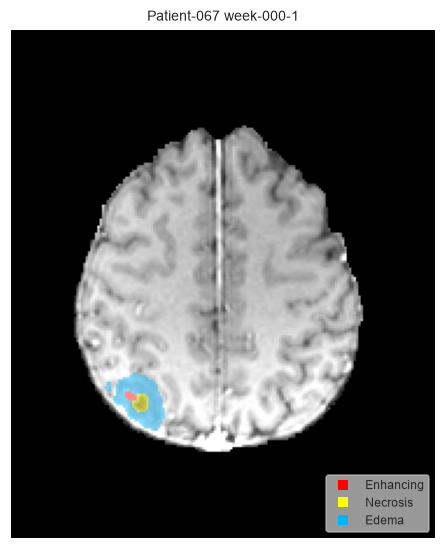

In [21]:
TISSUE_COLOR = {"Enhancing": (1, 0, 0), "Necrosis": (1, 1, 0), "Edema": (0, 0.7, 1)}

def overlay_axial(patient, tp, ax, title=None):
    img = np.asanyarray(load_nifti_from_zip(m_dbt_ss(patient, tp, "ct1")).dataobj).astype(float)
    lab_map = infer_label_map(patient, tp)
    mask = np.asanyarray(load_nifti_from_zip(m_dbt_mask(patient, tp)).dataobj).astype(int)
    enh_labels = [l for l, t in lab_map.items() if t == "Enhancing"]
    sel = enh_labels[0] if enh_labels else max((l for l in np.unique(mask) if l > 0),
                                               key=lambda l: (mask == l).sum(), default=0)
    z = int(np.argmax((mask == sel).sum(axis=(0, 1)))) if sel else mask.shape[2] // 2
    bg = np.rot90(img[:, :, z]); mk = np.rot90(mask[:, :, z])
    ax.imshow(bg, cmap="gray", vmax=np.percentile(bg, 99))
    rgba = np.zeros((*mk.shape, 4))
    for l, t in lab_map.items():
        c = TISSUE_COLOR.get(t, (1, 1, 1))
        rgba[mk == l] = (*c, 0.45)
    ax.imshow(rgba); ax.axis("off")
    ax.set_title(title or f"{patient} {tp} (z={z})", fontsize=9)

# pick an example patient that has masks in the zip and several timepoints
cand = vol_dbt["Patient"].value_counts().index
example = next((p for p in cand
                if m_dbt_mask(p, vol_dbt[vol_dbt["Patient"] == p].iloc[0]["Date"]) in ZIP_MEMBERS),
               cand[0])
etps = [d for d in sorted(vol_dbt[vol_dbt["Patient"] == example]["Date"],
                          key=lambda t: parse_timepoint(t)[0])
        if m_dbt_mask(example, d) in ZIP_MEMBERS]
print("Example patient:", example, "| timepoints with masks:", len(etps))

fig, ax = plt.subplots(figsize=(6, 6))
overlay_axial(example, etps[0], ax, title=f"{example} {etps[0]}")
handles = [plt.Line2D([0], [0], marker="s", ls="", mfc=c, mec="none", label=t)
           for t, c in TISSUE_COLOR.items()]
ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.6)
plt.show()

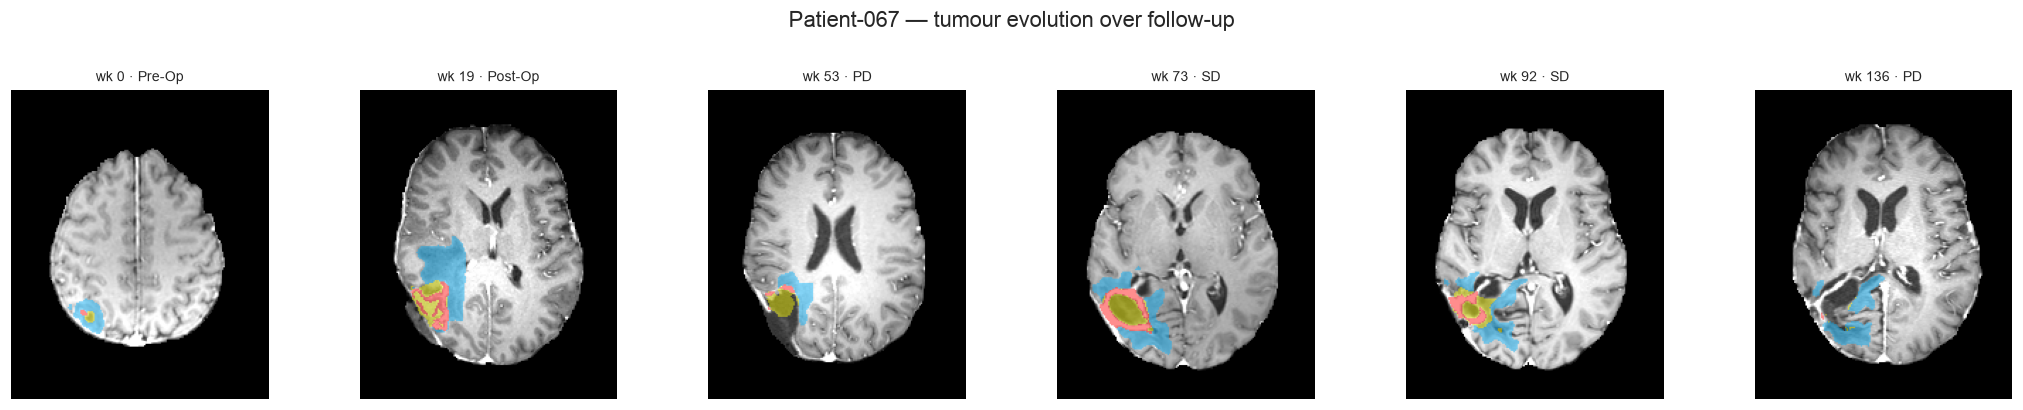

In [22]:
# Longitudinal montage: same patient across timepoints
pick = etps[:: max(1, len(etps) // 6)][:6]
fig, axes = plt.subplots(1, len(pick), figsize=(3.2 * len(pick), 3.6))
if len(pick) == 1:
    axes = [axes]
for ax, tp in zip(axes, pick):
    wk = parse_timepoint(tp)[0]
    rat = rano[(rano["Patient"] == example) & (rano["Date"] == tp)]["Rating_clean"]
    lab = f"wk {wk}" + (f" · {rat.iloc[0]}" if len(rat) else "")
    overlay_axial(example, tp, ax, title=lab)
fig.suptitle(f"{example} — tumour evolution over follow-up", y=1.03)
plt.tight_layout(); plt.show()

## M10 — Full radiomics EDA

The pyradiomics tables carry ~100 features per compartment. We examine **redundancy** (they are highly correlated), reduce with **PCA** coloured by RANO, and rank **which features separate progression (PD) from stable disease (SD)** on the enhancing compartment — a shortlist for any downstream model.

Feature matrix: 582 enhancing observations × 107 features


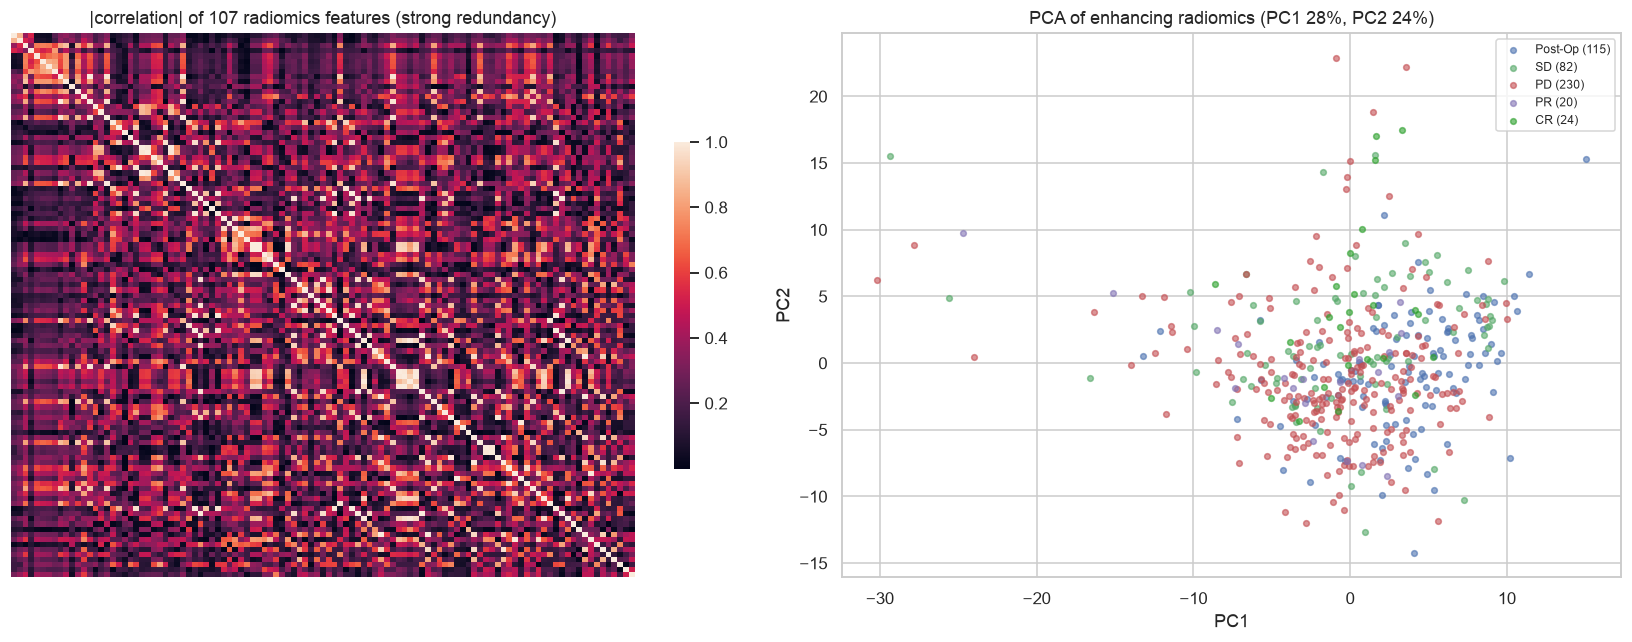

In [23]:
feat_cols = [c for c in rad_dbt.columns if c.startswith("original_")]
enh_feats = rad_dbt[(rad_dbt["Sequence"] == "CT1") &
                    (rad_dbt["Label name"] == "Contrast-enhancing")].copy()
X = enh_feats[["Patient", "Time point"] + feat_cols].dropna()
X = X.merge(rano[["Patient", "Date", "Rating_clean"]].rename(columns={"Date": "Time point"}),
            on=["Patient", "Time point"], how="left")
print(f"Feature matrix: {X.shape[0]} enhancing observations × {len(feat_cols)} features")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
corr = X[feat_cols].corr().abs()
sns.heatmap(corr, cmap="rocket", ax=axes[0], cbar_kws={"shrink": .6}, xticklabels=False, yticklabels=False)
axes[0].set_title(f"|correlation| of {len(feat_cols)} radiomics features (strong redundancy)")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Z = StandardScaler().fit_transform(X[feat_cols].values)
pcs = PCA(n_components=2).fit(Z)
P = pcs.transform(Z)
for c in ["Post-Op", "SD", "PD", "PR", "CR"]:
    m = X["Rating_clean"] == c
    if m.sum():
        axes[1].scatter(P[m.values, 0], P[m.values, 1], s=14, alpha=0.6,
                        color=RANO_PALETTE.get(c, "0.3"), label=f"{c} ({m.sum()})")
axes[1].set_title(f"PCA of enhancing radiomics "
                  f"(PC1 {pcs.explained_variance_ratio_[0]*100:.0f}%, "
                  f"PC2 {pcs.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

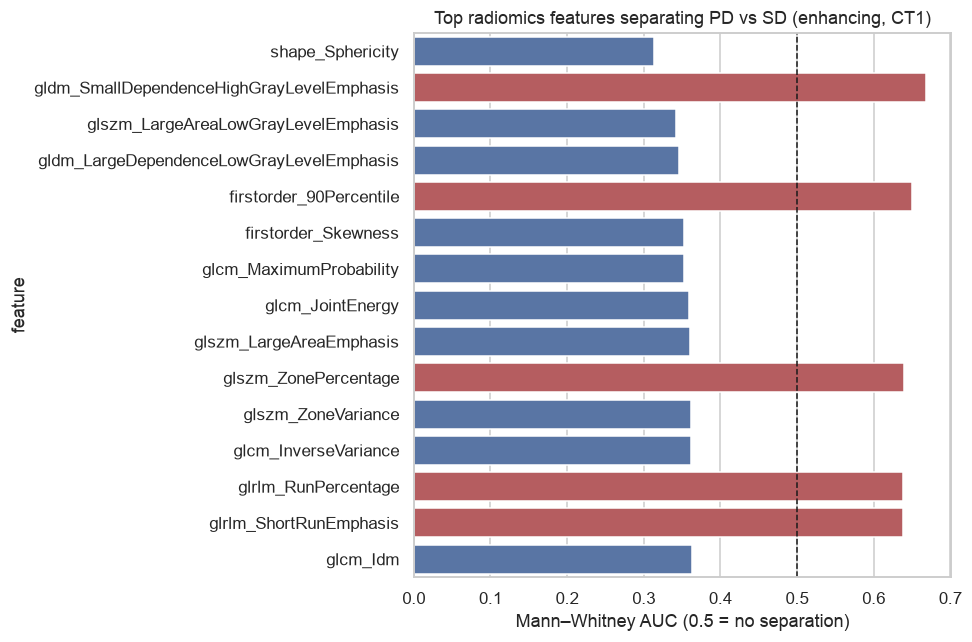

,feature,AUC,p
0,shape_Sphericity,0.313759,5.520366e-07
1,gldm_SmallDependenceHighGrayLevelEmphasis,0.667948,6.319895e-06
2,glszm_LargeAreaLowGrayLevelEmphasis,0.341967,2.149409e-05
3,gldm_LargeDependenceLowGrayLevelEmphasis,0.346580,3.711613e-05
4,firstorder_90Percentile,0.650027,5.495536e-05
5,firstorder_Skewness,0.352094,6.994997e-05
6,glcm_MaximumProbability,0.352572,7.382049e-05
7,glcm_JointEnergy,0.359358,1.561205e-04
8,glszm_LargeAreaEmphasis,0.360392,1.745039e-04
9,glszm_ZonePercentage,0.639396,1.785183e-04


In [24]:
# Which features best separate PD from SD? (Mann-Whitney AUC as effect size)
from scipy.stats import mannwhitneyu
pd_ = X[X["Rating_clean"] == "PD"]; sd_ = X[X["Rating_clean"] == "SD"]
rows = []
for f in feat_cols:
    a, b = pd_[f].dropna(), sd_[f].dropna()
    if len(a) > 5 and len(b) > 5:
        u = mannwhitneyu(a, b, alternative="two-sided")
        auc = u.statistic / (len(a) * len(b))
        rows.append({"feature": f.replace("original_", ""), "AUC": auc,
                     "abs_effect": abs(auc - 0.5), "p": u.pvalue})
eff = pd.DataFrame(rows).sort_values("abs_effect", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x="AUC", y="feature", data=eff, ax=ax,
            palette=["#C44E52" if a > 0.5 else "#4C72B0" for a in eff["AUC"]])
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set_title("Top radiomics features separating PD vs SD (enhancing, CT1)")
ax.set_xlabel("Mann–Whitney AUC (0.5 = no separation)")
plt.tight_layout(); plt.show()
display(eff[["feature", "AUC", "p"]].reset_index(drop=True))

## M11 — Data-quality / trackability synthesis

A per-patient scorecard summarising everything relevant to building the tracking pipeline: baseline availability, follow-up length, whether progression was observed, pseudoprogression flags, segmentation coverage, and scanner switches mid-follow-up.

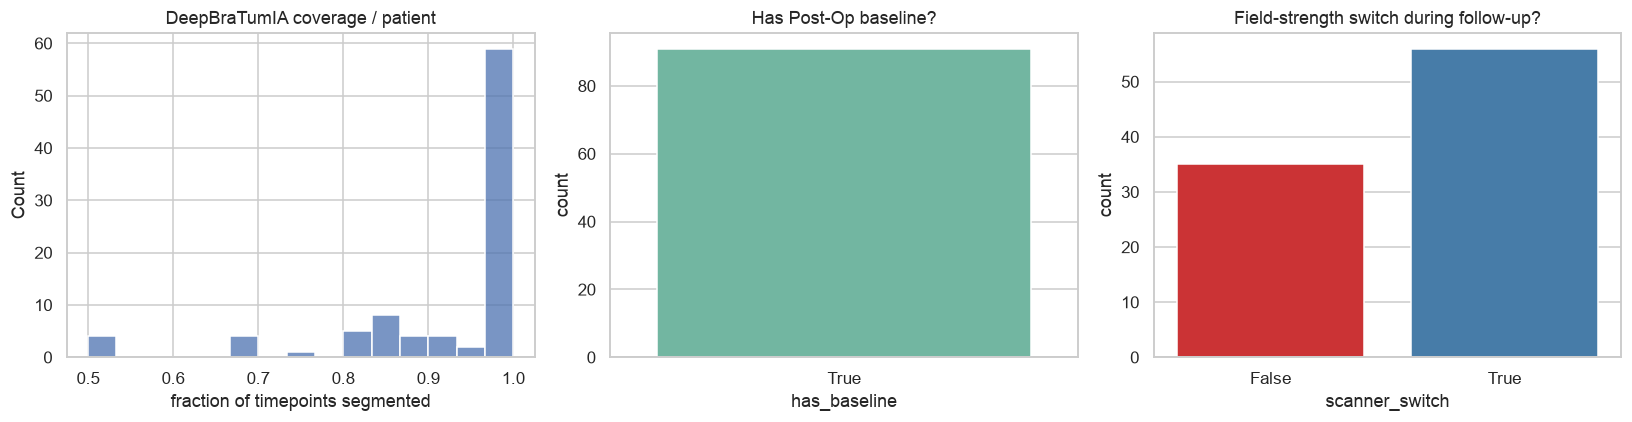

Cohort trackability summary:
  patients with Post-Op baseline : 91/91
  patients who progressed (PD)   : 73/91
  patients w/ full seg coverage  : 59/91
  patients w/ scanner switch     : 56/91


,Patient,n_timepoints,followup_wk,has_baseline,ever_PD,pseudo_flags,seg_coverage,field_strengths,scanner_switch
66,Patient-067,21,167.0,True,True,0,0.952381,2,True
30,Patient-031,18,190.0,True,True,0,1.000000,2,True
72,Patient-073,17,242.0,True,True,0,1.000000,2,True
77,Patient-078,17,119.0,True,True,0,1.000000,2,True
14,Patient-015,14,146.0,True,True,0,1.000000,1,False
5,Patient-006,14,135.0,True,True,0,1.000000,2,True
28,Patient-029,14,240.0,True,True,0,0.933333,1,False
22,Patient-023,14,127.0,True,True,0,0.857143,1,False
41,Patient-042,14,82.0,True,True,0,1.000000,2,True
71,Patient-072,13,105.0,True,True,0,1.000000,1,False


In [ ]:
comp_local = complete.copy()
comp_local["DeepBraTumIA"] = comp_local["DeepBraTumIA"].astype(str).str.strip().eq("x").astype(int)
seg_cov = comp_local.groupby("Patient")["DeepBraTumIA"].mean()
scanner_switch = mrinfo.groupby("Patient")["Field strength"].nunique()

summary = pd.DataFrame({
    "n_timepoints":   rano.groupby("Patient").size(),
    "followup_wk":    rano.groupby("Patient")["week"].max() - rano.groupby("Patient")["week"].min(),
    "has_baseline":   rano.assign(b=rano["Rating_clean"].eq("Post-Op")).groupby("Patient")["b"].any(),
    "ever_PD":        rano.assign(b=rano["Rating_clean"].eq("PD")).groupby("Patient")["b"].any(),
    "pseudo_flags":   rano.assign(b=rano["Rating_clean"].eq("PD") & rano["lt3m"]).groupby("Patient")["b"].sum(),
    "seg_coverage":   seg_cov,
    "field_strengths": scanner_switch,
}).reset_index()
summary["scanner_switch"] = summary["field_strengths"] > 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(summary["seg_coverage"], bins=15, ax=axes[0], color="#4C72B0")
axes[0].set_title("DeepBraTumIA coverage / patient"); axes[0].set_xlabel("fraction of timepoints segmented")
sns.countplot(x="has_baseline", data=summary, ax=axes[1], palette="Set2")
axes[1].set_title("Has Post-Op baseline?")
sns.countplot(x="scanner_switch", data=summary, ax=axes[2], palette="Set1")
axes[2].set_title("Field-strength switch during follow-up?")
plt.tight_layout(); plt.show()

print("Cohort trackability summary:")
print(f"  patients with Post-Op baseline : {summary['has_baseline'].sum()}/{len(summary)}")
print(f"  patients who progressed (PD)   : {summary['ever_PD'].sum()}/{len(summary)}")
print(f"  patients w/ full seg coverage  : {(summary['seg_coverage']==1).sum()}/{len(summary)}")
print(f"  patients w/ scanner switch     : {summary['scanner_switch'].sum()}/{len(summary)}")
display(summary.sort_values("n_timepoints", ascending=False).head(10))

## Takeaways & next steps

**What the EDA establishes for the tracking pipeline:**
- **Labels** exist as expert RANO calls with irregular longitudinal spacing (M2/M3) — the pipeline must handle uneven sampling and a post-op baseline.
- The **enhancing compartment** is the RANO-critical signal; volumetric %-change broadly tracks the expert label (M6) and the two segmenters agree reasonably (M8), but with real disagreement to characterise.
- RANO is defined in **2D SPD** while segmentation gives **3D volume** (M7) — decide the tracking metric deliberately.
- **Pseudoprogression** (<3 months / in-field, M3) and **scanner heterogeneity** (M5) are the two biggest confounders to design around.
- The **`Label name` string** is authoritative; raw mask integers use a different convention (M5).

**Suggested next session:** build the segmentation → longitudinal-registration → per-timepoint SPD/volume extraction → RANO-decision module, validated against these expert labels.